In [1]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 24.7 MB/s eta 0:00:00


Importamos librerias

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from Bio import Entrez, SeqIO

import numpy as np
from Bio.Seq import Seq
import matplotlib.pyplot as plt
from scipy import ndimage
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
import re



/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Ejercicio 3.1 Dot-Plot y filtros

a) cree una matriz de ceros (de dimensión de acuerdo a las longitudes de seq1 y seq2) y luego recorra todas las casillas poniendo 1 donde hay un match y 0 donde hay mismatch (consejo pruebe con una matriz más pequeña y luego vaya por la  completa).

b) Arme un modulo para graficar el dot-plot.

c) Programe un filtro que -opere sobre el dot-plot obtenido (el window-size “w” debería ser una variable a modificar), y reanalice los resultados. Hay varias alternativas para programar el filtro, como ser relacionadas con si las ventanas se encuentran superpuestas o son adyacentes, y si el dotplot es reemplazado por el dotplot de las ventanas y/o las mismas son solo utilizadas como filtro. Ademas se puede setear el umbral (vea el grafico para mayor claridad). Programe y compare las diferentes opciones.

# Funcion para generar el dotplot

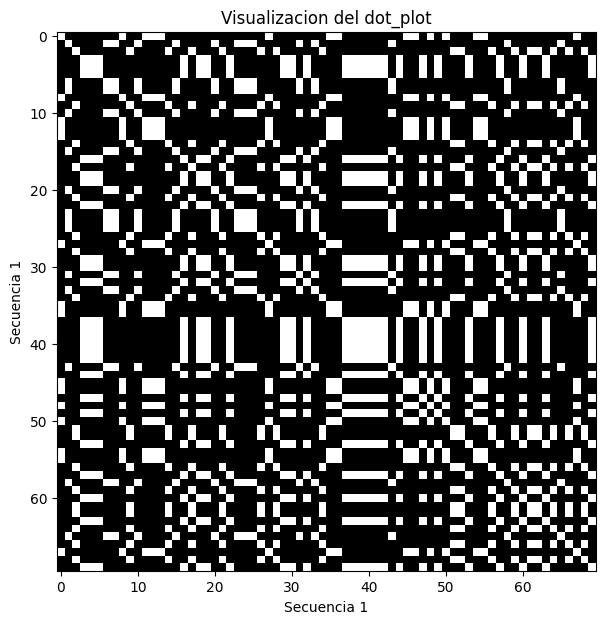

In [3]:
# Me quedo solo con la secuencia que es lo que me interesa
#seq1 = records[0].seq
#seq2 = records[1].seq

seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
seq2 = "GCTCTTAATCATCCATTGTCGGGTCATGGGATYGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA"

seq1 = seq1.replace("R", "A")
seq2 = seq2.replace("Y", "T")


def generar_dotplot(seq1, seq2):
    # convertimos las secuencias fasta a string
    seq1, seq2 = str(seq1), str(seq2)

    # Armamos matriz de ceros
    dot_plot = np.zeros((len(seq1), len(seq2)))
    # Recorremos ambas secuencias y completamos la matriz
    # Consideramos seq1 para filas y seq2 para columnas
    for i, aa1 in enumerate(seq1):
        for j, aa2 in enumerate(seq2):
            if aa1 == aa2:
                dot_plot[i,j] = 1
            else:
                dot_plot[i,j] = 0
    return dot_plot

dotplot = generar_dotplot(seq1,seq1)
plt.figure(figsize=(7,7))
plt.imshow(dotplot, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.xlabel("Secuencia 1")
plt.ylabel("Secuencia 1")
plt.title("Visualizacion del dot_plot")
plt.show()



# Funcion que filtra una imagen
##Dada una imagen, la convolucionamos con un kernel; y las posiciones de la imagen convolucionada cuyo valor supera o iguala el umbral las define como 1, y a las que no como 0.

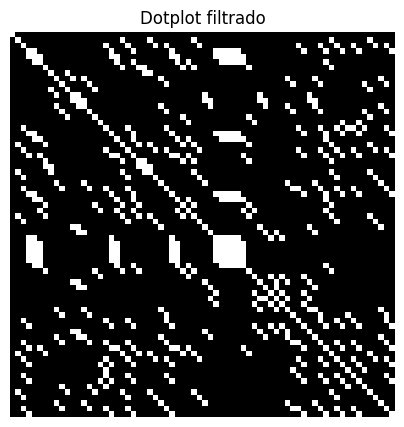

In [4]:
def filtro_solapado(imagen,kernel = np.array([[1,0,0],[0,0,0],[0,0,1]], dtype=np.uint8) ,umbral = 1):
    # Conteo de vecinos
    vecinos_validos = ndimage.convolve(imagen, kernel, mode="constant", cval=0)

    resultado = np.where((imagen == 1) & (vecinos_validos >= umbral), 1, 0)
    return resultado

imagen_filtrada = filtro_solapado(dotplot, np.array([[1,0,0],[0,0,0],[0,0,1]], dtype=np.uint8), umbral=1)

plt.figure(figsize=(5,5))
plt.imshow(imagen_filtrada, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title("Dotplot filtrado")
plt.axis("off")
plt.show()




## Probaremos usando los siguientes filtros

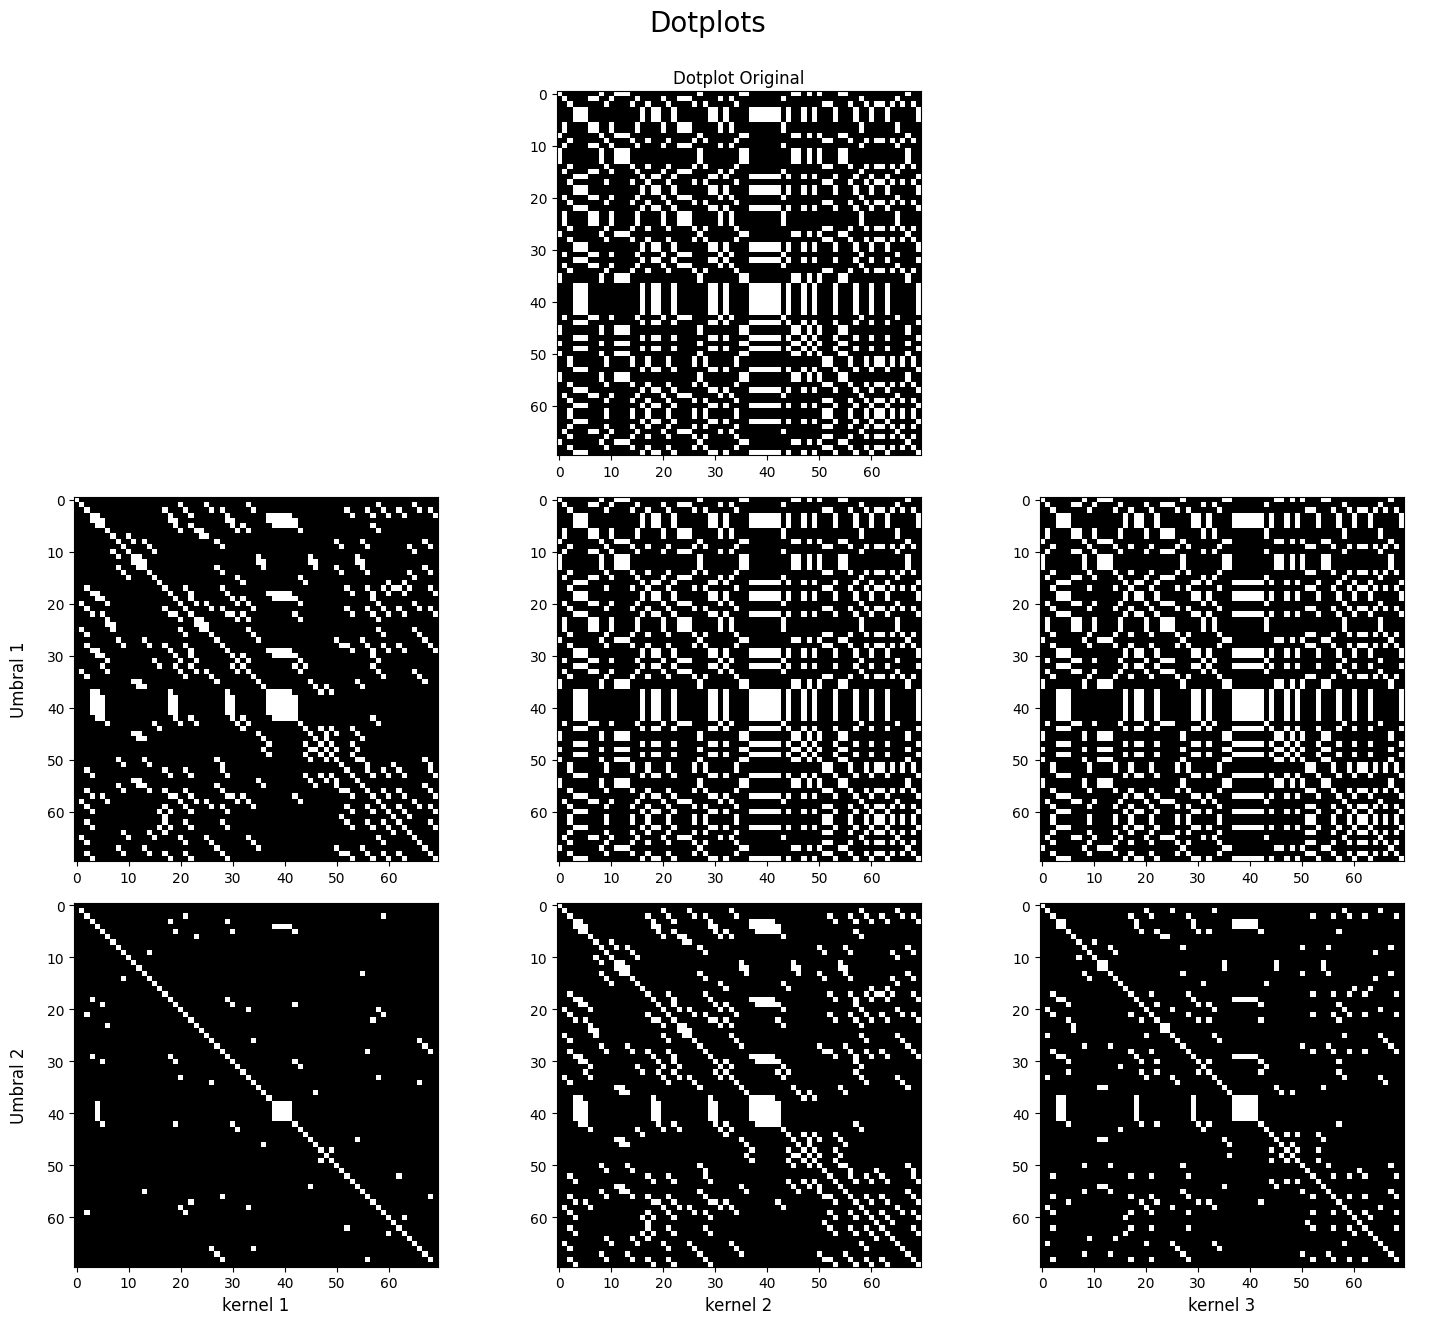

In [5]:
kernel_1 = np.array([[1,0,0],[0,0,0],[0,0,1]], dtype=np.uint8)
kernel_2 = np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=np.uint8)
kernel_3 = np.array([[1,0],[0,1]], dtype=np.uint8)
tuplas_kernel_umbral = [(kernel_1,1), (kernel_2,1), (kernel_3,1),
                        (kernel_1,2), (kernel_2,2) ,(kernel_3,2)]
#Dotplot sin filtrar
dotplot_original = generar_dotplot(seq1,seq1)
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
axs[0,0].axis("off")
axs[0,2].axis("off")
axs[0,1].imshow(dotplot_original, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
f,c = 0,0
for i,(kernel,umbral) in enumerate(tuplas_kernel_umbral):
    if i % 3 == 0 and i != 0:
        f += 1
        c = 0
    dotplot_solapado = filtro_solapado(dotplot_original, kernel, umbral)
    axs[f+1,c].imshow(dotplot_solapado, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    c +=1



# Títulos verticales para las filas
axs[1,0].set_ylabel(f'Umbral {1}', rotation=90, size='large', labelpad=20, va='center')
axs[2,0].set_ylabel(f'Umbral {2}', rotation=90, size='large', labelpad=20, va='center')

# Título horizontal para el subplot [0,1]
axs[0,1].set_title('Dotplot Original', size='large')


# Etiquetas de las columnas debajo
for ax, k in zip(axs[2,:], [1,2,3]):
    ax.set_xlabel('kernel ' + str(k), size='large')

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Dejar espacio abajo para el título "Kernel"


plt.suptitle("Dotplots", fontsize = 20)
plt.show()



##Filtro de reduccion

(np.float64(-0.5), np.float64(34.5), np.float64(34.5), np.float64(-0.5))

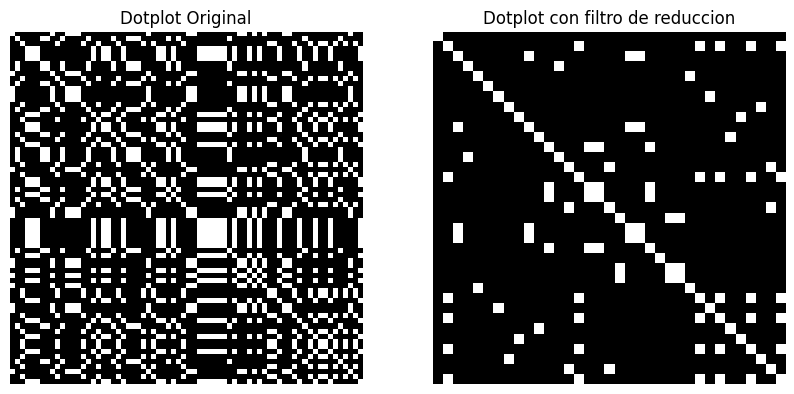

In [6]:
def filtro_reduccion(imagen, objetivos):
    filas, columnas = imagen.shape[0],  imagen.shape[1]

    # dimensiones reducidas
    cant_filas = filas // 2 if filas % 2 == 0 else (filas - 1) // 2
    cant_columnas = columnas // 2 if columnas % 2 == 0 else (columnas - 1) // 2

    #objetivo = np.array([[1,0],
    #                     [0,1]], dtype=np.uint8)


    imagen_filtrada = np.zeros((cant_filas, cant_columnas), dtype=np.uint8)

    for i in range(0, filas - 1, 2):
        for j in range(0, columnas - 1, 2):
            ventana = imagen[i:i+2, j:j+2]
            #imagen_filtrada[i//2, j//2] = 1 if np.array_equal(objetivo, ventana) else 0
            #Si la ventana es igual a alguno de los filtros, entonces
            imagen_filtrada[i//2, j//2] = 1 if sum([np.array_equal(objetivo, ventana) for objetivo in objetivos]) > 0 else 0

    return imagen_filtrada

def get_objetivos():
  return  [np.array([[1,0], [0,1]], dtype=np.uint8),
           np.array([[1,1], [1,1]], dtype=np.uint8),
           np.array([[1,1],[0,1]], dtype=np.uint8),
           np.array([[1,0],[1,1]], dtype=np.uint8)]

objetivos = get_objetivos()

seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
seq1 = seq1.replace("R", "A")

dotplot = generar_dotplot(seq1,seq1)
dotplot_filtrado = filtro_reduccion(dotplot,objetivos)
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(dotplot, cmap='gray', clim=(0,1))
axs[0].set_title("Dotplot Original")
axs[0].axis("off")

axs[1].imshow(dotplot_filtrado, cmap='gray', clim=(0,1))
axs[1].set_title("Dotplot con filtro de reduccion")
axs[1].axis("off")


#Funcion que obtiene matriz de puntajes acumulados
###El siguiente algoritmo consigue un alineamiento global, por lo que considera que en una matriz de mxn la solucion empieza en la posicion (0,0) y el camino optimo terminara en la celda (m,n).

In [7]:
def inicializar_matrices(n, m, gap_open, gap_ext):
  DP = np.zeros((n,m), dtype=int)
  DP[0,1] = gap_open
  DP[1,0] = gap_open
  for i in range(2,n):
    DP[i,0] = DP[i-1,0] + gap_ext
  for i in range(2,m):
    DP[0,i] = DP[0,i-1] + gap_ext

  hay_gap_en_seq_horizontal = np.zeros((n,m), dtype=int)
  hay_gap_en_seq_vertical = np.zeros((n,m), dtype=int)
  for i in range(1,n):
    hay_gap_en_seq_horizontal[i,0] = 1
  for i in range(1,m):
    hay_gap_en_seq_vertical[0,i] = 1

  return DP , hay_gap_en_seq_horizontal, hay_gap_en_seq_vertical

def puntaje_acum(dotplot,match,mismatch, gap_open, gap_ext):
    #seq1 es la secuencia vertical
    #seq2 es la secuecnia horizontal
    long_seq1,long_seq2= len(dotplot), len(dotplot[0])
    DP, hay_gap_en_seq_horizontal, hay_gap_en_seq_vertical = inicializar_matrices(long_seq1+1, long_seq2+1, gap_open, gap_ext)

   # print(dotplot.shape)
    #print(DP.shape)
    for i in range(1, long_seq1+1):
        for j in range(1, long_seq2+1):
            up,left,diagonal =0,0,0
            if i > 0:
              up = DP[i-1, j] + (gap_ext if hay_gap_en_seq_horizontal[i-1][j] else gap_open) #Celda superior
            if j > 0:
              left = DP[i, j-1] + (gap_ext if hay_gap_en_seq_vertical[i][j-1] else gap_open) #Celda izquierda
            if j > 0 and i > 0:
              diagonal = DP[i-1, j-1] + (match if dotplot[i-1, j-1] else mismatch) #Celda en diagonal

            mejor_pje = max(up, left, diagonal)
            DP[i,j] =  mejor_pje

            #Si el mejor puntaje no proviene de la diagonal y si o si debo poner gap
            if mejor_pje == up:
                hay_gap_en_seq_horizontal[i,j] = 1
            elif mejor_pje == left:
                hay_gap_en_seq_vertical[i,j] = 1
    return DP

np.set_printoptions(threshold=np.inf)

seq1=  'ACGACTG'
seq2 =  'ACTGACG'
dotplot = generar_dotplot(seq1,seq2)
print("Ejemplo de matriz de puntaje acumulados")
print(puntaje_acum(dotplot,1,0,-3,-1))

Ejemplo de matriz de puntaje acumulados
[[ 0 -3 -4 -5 -6 -7 -8 -9]
 [-3  1 -2 -3 -4 -5 -6 -7]
 [-4 -2  2 -1 -2 -3 -4 -5]
 [-5 -3 -1  2  0 -2 -3 -3]
 [-6 -4 -2 -1  2  1 -2 -3]
 [-7 -5 -3 -2 -1  2  2 -1]
 [-8 -6 -4 -2 -2 -1  2  2]
 [-9 -7 -5 -4 -1 -2 -1  3]]


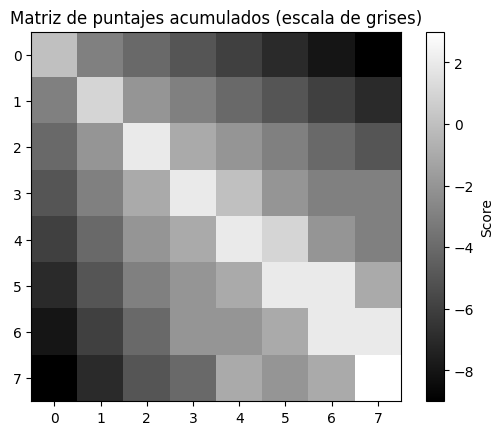

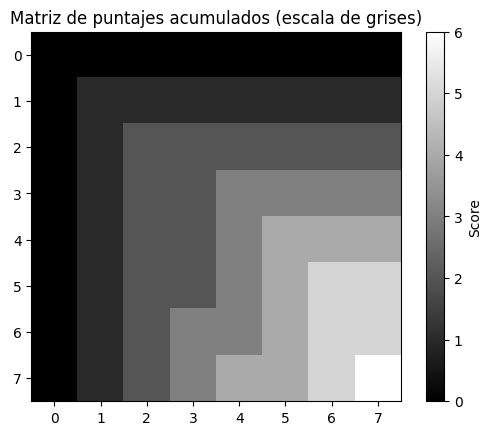

In [8]:

matriz_puntaje_acum = puntaje_acum(dotplot,1,0,-3,-1)
plt.imshow(matriz_puntaje_acum, cmap="gray", origin="upper")
plt.colorbar(label="Score")
plt.title("Matriz de puntajes acumulados (escala de grises)")
plt.show()

matriz_puntaje_acum = puntaje_acum(dotplot,1,0,0,0)
plt.imshow(matriz_puntaje_acum, cmap="gray", origin="upper")
plt.colorbar(label="Score")
plt.title("Matriz de puntajes acumulados (escala de grises)")
plt.show()


Con la funcion de arriba podemos ver donde se obtiene el maximo alineamiento (aca que no penalizamos con numeros negativos seguro que va a andar por la esquina inferior derecha, pero si sumamos penalidad por gaps, podriamos tener que el mejor alineamiento no estaria por ahi. Es por eso que cuando reconstruye el camino, le pasamos la celda desde donde tiene que reconstruir. Aca lo hacemos manualmente pidiendolo, pero si quisieramos podriamos pedir que arranque desde el puntaje maximo para automatizarlo)

## Funciones auxiliares para obtener y mostrar el mejor alineamiento

In [9]:
#Obtiene el maximo valor de una matriz (en nuestro caso la matriz de puntajes)
def max_matriz(matriz):
    max_valor = matriz[0][0]
    posicion = (0, 0)
    for i, fila in enumerate(matriz):
        for j, elem in enumerate(fila):
            if elem > max_valor:
                max_valor = elem
                posicion = (i, j)
    return posicion

#Dadas dos secuencias seq1 y seq2, una matriz de puntajes y la fila y columna actual, obtenemos
#la siguiente posicion del mejor camino para recorrer el doplot
def seguir_por(seq1, seq2, matriz, fila_inicial, columna_inicial):
    diagonal = matriz[fila_inicial - 1][columna_inicial - 1]
    horizontal = matriz[fila_inicial][columna_inicial - 1]
    vertical = matriz[fila_inicial - 1][columna_inicial]
    maximo = max(diagonal, horizontal, vertical)

    #MATCH
    if maximo == diagonal and seq1[fila_inicial - 1] == seq2[columna_inicial - 1]:
        return "d,m"
    #MISMATCH
    elif maximo == diagonal:
        return "d,mm"
    #VERTICAL
    elif maximo == vertical:
        return "vertical"
    #HORIZONTAL
    else:
        return "horizontal"


Como iniciamos en la casilla de la matriz de puntajes con mayor score, es probable que parte del camino en el doplot no quede definido

 - rellenar_final_alineamiento agrega las coordenadas del camino correspondientes a la parte inferior derecha del dotplot;

 - rellenar_inicio_alineamiento agrega las coordenadas del camino correspondientes a la parte superior izquierda del dotplot.



In [10]:
def rellenar_final_alineamiento(f,c, seq1, seq2):
    alineamiento1, alineamiento2, matchs = [], [], []
    camino = []
    i,j = f, c
    if(i == len(seq1) and j <len(seq2)): #Relleno nucleotidos asi aparecen las secuencias completas
      while j < len(seq2):
            alineamiento2.append(seq2[j])
            alineamiento1.append("-")
            matchs.append(" ")
            camino.append((i,j))
            j = j+1
    if(j == len(seq2) and i <len(seq1)): #Relleno nucleotidos asi aparecen las secuencias completas
      while i < len(seq1):
            alineamiento1.append(seq1[i])
            alineamiento2.append("-")
            matchs.append(" ")
            camino.append((i,j))
            i = i+1

    camino = camino[::-1]
    alineamiento1 = alineamiento1[::-1]
    alineamiento2 = alineamiento2[::-1]
    return camino, alineamiento1, alineamiento2, matchs

def rellenar_inicio_alineamiento(f,c,seq1, seq2, alineamiento1, alineamiento2, camino, matchs):
      if(c == 0 and f > 0): #Relleno nucleotidos asi aparecen las secuencias completas
            while f> 0:
                  alineamiento1.append(seq1[f-1])
                  alineamiento2.append("-")
                  matchs.append(" ")
                  camino.append((f,c))
                  f = f-1
      if(c > 0 and f == 0):
        while c> 0:
            alineamiento1.append("-")
            alineamiento2.append(seq2[c-1])
            matchs.append(" ")
            camino.append((f,c))
            c = c-1
      return f,c, alineamiento1, alineamiento2, camino, matchs

In [42]:
import re
def imprimir_alineamiento(alineamiento1, alineamiento2, camino,tipo_alineamiento, matchs ,match,mismatch, gap_open, gap_ext):
    gaps_alineamiento1 = "".join(alineamiento1)
    gaps_alineamiento2 = "".join(alineamiento2)

    score = sum([1 for letra in matchs if letra == "*"]) * match

    gaps_alineamiento1= re.findall(r"-+", gaps_alineamiento1)
    gaps_alineamiento2= re.findall(r"-+", gaps_alineamiento2)
    for gaps in gaps_alineamiento1:
        score += gap_open + gap_ext * (len(gaps)-1)
    for gaps in gaps_alineamiento2:
        score += gap_open + gap_ext * (len(gaps)-1)
    print("Score:", score, tipo_alineamiento)
    print("".join(reversed(alineamiento1)))
    print("".join(reversed(alineamiento2)))
    print("".join(reversed(matchs)))
    return score

In [64]:
def mostrar_alineamiento(seq1,seq2,dotplot, tipo_alineamiento, match,mismatch, gap_open, gap_ext, return_score = False):
 # seq1 es la vertical
 # seq2 es la horizontal
    matriz_puntaje = puntaje_acum(dotplot,match,mismatch, gap_open, gap_ext)
    alineamiento1, alineamiento2, matchs = [], [], []
    camino = []
    fila_pje_maximo, col_pje_maximo = max_matriz(matriz_puntaje)
    fila_pje_maximo, col_pje_maximo= len(matriz_puntaje)-1, len(matriz_puntaje[0])-1
    #print(matriz_puntaje)
#    print(f"Fila: {f} Col: {c} ")
    camino, alineamiento1, alineamiento2, matchs = rellenar_final_alineamiento(fila_pje_maximo, col_pje_maximo, seq1, seq2)
    f, c = fila_pje_maximo, col_pje_maximo
    while f > 0 and c > 0:
        camino.append((f,c))
      #Me devuelve la siguiente posicion a recorrer en la matriz de puntajes
        siguiente = seguir_por(seq1, seq2, matriz_puntaje, f, c )

        # Asciendo por la diagonal y hay match
        if siguiente == "d,m":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append(seq2[c-1])
            matchs.append("*")
            f, c = f-1, c-1
        #Asciendo por la diagonal y hay mismatch
        elif siguiente == "d,mm":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append(seq2[c-1])
            matchs.append(" ")
            f, c = f-1, c-1
        #Asciendo con gap en la secuencia vertical
        elif siguiente == "vertical":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append("-")
            matchs.append(" ")
            f = f-1
        elif siguiente == "horizontal":
            alineamiento1.append("-")
            alineamiento2.append(seq2[c-1])
            matchs.append(" ")
            c = c-1
   # print(f"Fila: {f} Col: {c} ")
    f,c, alineamiento1, alineamiento2, camino, matchs = rellenar_inicio_alineamiento(f,c,seq1,seq2, alineamiento1, alineamiento2, camino, matchs)

    score = imprimir_alineamiento(alineamiento1, alineamiento2, camino,tipo_alineamiento, matchs ,match,mismatch, gap_open, gap_ext)
    #Invertimos el camino
    camino = camino[::-1]
    return camino, score

seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
seq2 = "GCTCTTAATCATCCATTGTCGGGTCATGGGATYGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA"

seq1 = seq1.replace("R", "A")
seq2 = seq2.replace("Y", "T")
dotplot = generar_dotplot(seq1,seq2)
coords = mostrar_alineamiento(seq1,seq2, dotplot,'con dotplot sin filtrar',1,0,-3,-1)

alignments = pairwise2.align.globalms(seq1, seq2,1,0,-3,-1)
# Mostrar el mejor alineamiento
print(format_alignment(*alignments[0]))



Score: 18 con dotplot sin filtrar
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATATGGATTGACGAGGAGCGTGA
GCTCTTAATCATCCATTGTCGGGTCATGGGATTGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA
 *      *  *     *   *  *   * *      *      **  ****   *       *     *
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATATGGATTGACGAGGAGCGTGA
.|......|..|.....|...|..|...|.|......|......||..||||...|.......|.....|
GCTCTTAATCATCCATTGTCGGGTCATGGGATTGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA
  Score=18



## Funcion que grafica un camino (a partir de sus coordenadas) en un dotplot

Score: 70 con alineamiento sin filtrar
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATATGGATTGACGAGGAGCGTGA
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATATGGATTGACGAGGAGCGTGA
**********************************************************************


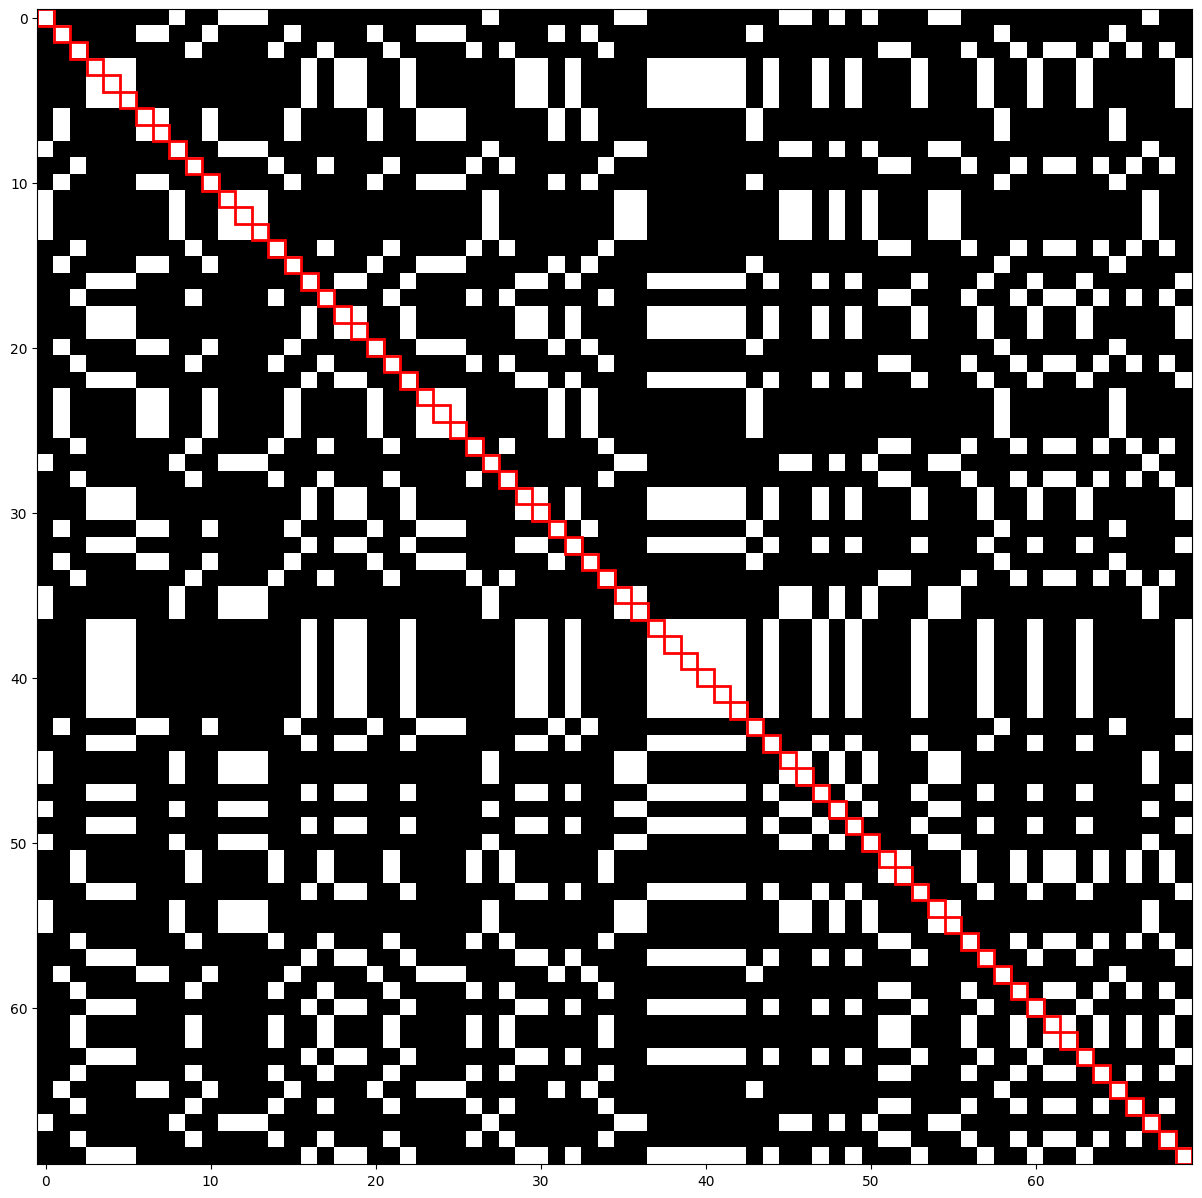

In [45]:
def dibujar_camino_en_dotplot(dotplot, backtrack, ax=None):
    n, m = dotplot.shape

    # Si no me pasan ax, creo uno nuevo
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 15))

    # Dibujo el dotplot (0/1)
    ax.imshow(dotplot, cmap=plt.cm.colors.ListedColormap(["black", "white"]), origin="upper")

    # Trazo el camino hacia atrás
    for cord in backtrack:
        i, j = cord[0], cord[1]
        rect = patches.Rectangle((j-0.5, i-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    rect = patches.Rectangle((0-0.5, 0-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    return ax

# Supongamos que ya tenés dotplot y backtrack definidos
dotplot = generar_dotplot(seq1,seq1)
coords,score = mostrar_alineamiento(seq1, seq1, dotplot,'con dotplot sin filtrar', 1,0,-3,-1)
ax = dibujar_camino_en_dotplot(dotplot, coords)

# Mostrar la figura
plt.show()



Veamos todo junto para poder comparar bien

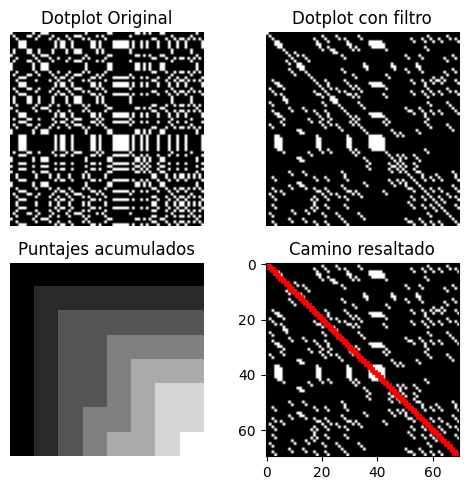

In [14]:
imagen_filtrada = filtro_solapado(dotplot)

fig, axs = plt.subplots(2, 2, figsize=(5, 5))

# Dotplot Original
axs[0,0].imshow(dotplot, cmap='gray', vmin=0, vmax=1)
axs[0,0].set_title("Dotplot Original")
axs[0,0].axis("off")

# Dotplot Filtrado
axs[0,1].imshow(imagen_filtrada, cmap='gray', vmin=0, vmax=1)
axs[0,1].set_title("Dotplot con filtro")
axs[0,1].axis("off")

# Puntajes acumulados
axs[1,0].imshow(matriz_puntaje_acum, cmap='gray')
axs[1,0].set_title("Puntajes acumulados")
axs[1,0].axis("off")

# Camino resaltado en el cuarto subplot
dibujar_camino_en_dotplot(imagen_filtrada, coords, ax=axs[1,1])
axs[1,1].set_title("Camino resaltado")

plt.tight_layout()
plt.show()


3.1.h) Escriba un código que tome como entrada s1, s2 y el camino del dot-plot y sea capaz de mostrar el alineamiento en el formato deseado.

Notas: la dificultad esta en como poner los gaps. Recuerde que ir por la Horizontal implica poner un gap en la secuencia vertical (usualmente s2) y vice-versa.
 Recomendamos no programar de entrada, sino resolver la logica del código (para las opciones principales, D, H y V) en papel y luego ver como programarlo.

 i) Busque algún programa on-line (BLAST?) que haga alineamientos compare los resultados de sualgoritmo con el obtenido con BLAST

# Testeamos nuestro programa variando:
- Tipos de filtros
- Largos de las secuencias
- Identidad de las secuencias

Dado dos alineamientos (con gaps '-'), devuelve la lista de coordenadas (i,j) en el dotplot.

In [15]:
def path_from_alignment(aln1, aln2):
    path = []
    i, j = 0, 0
    for a, b in zip(aln1, aln2):
        if a != "-" and b != "-":   # diagonal
            i += 1
            j += 1
        elif a == "-" and b != "-": # gap en seq1 → mov horizontal
            j += 1
        elif a != "-" and b == "-": # gap en seq2 → mov vertical
            i += 1
        # guardar coordenada
        path.append((i, j))
    return path



La funcion 'evaluar_alineamientos' toma 2 secuencias y las alinea usando el dotplot original para luego graficar los dotplots e imprimir los alineamientos  

In [51]:
def evaluar_alineamientos(seq1, seq2, titulo,match,mismatch, gap_open, gap_ext):

      dotplot_original = generar_dotplot(seq1,seq2)
      dotplot_filtrado_solapado = filtro_solapado(dotplot_original)

      fig, axs = plt.subplots(1, 3, figsize=(30, 10))

      # Dotplot Original
      coords,score = mostrar_alineamiento(seq1, seq2, dotplot_original,'con alineamiento sin filtrar', match,mismatch, gap_open, gap_ext)
      axs[0] = dibujar_camino_en_dotplot(dotplot_original, coords, axs[0])
      axs[0].imshow(dotplot_original, cmap='gray', vmin=0, vmax=1)
      axs[0].set_title("Dotplot Original", fontsize = 25)
      axs[0].axis("off")

      print()
      # Dotplot Filtrado con solapamiento
      coords,score = mostrar_alineamiento(seq1, seq2, dotplot_filtrado_solapado,'con alineamiento con dotplot filtrado por solapamiento', match,mismatch, gap_open, gap_ext)
      axs[1] = dibujar_camino_en_dotplot(dotplot_filtrado_solapado, coords, axs[1])
      axs[1].imshow(dotplot_filtrado_solapado, cmap='gray', vmin=0, vmax=1)
      axs[1].set_title("Filtrado con solapamiento", fontsize = 25)
      axs[1].axis("off")

      print()
      alignments = pairwise2.align.globalms(seq1, seq2,match,mismatch, gap_open, gap_ext)
      alin = alignments[0]
      alin1, alin2 = alin.seqA, alin.seqB
      # Mostrar el mejor alineamiento
      print(format_alignment(*alignments[0]))
      print('con alineamiento de funcion pairwise2.align.globalms ')
      # Dotplot filtrado con reduccion
      coords = path_from_alignment( alin1, alin2)
      axs[2] = dibujar_camino_en_dotplot(dotplot_original, coords, axs[2])
      axs[2].imshow(dotplot_original, cmap='gray', vmin=0, vmax=1)
      axs[2].set_title("Devuelto por funcion de alineamiento", fontsize = 25)
      axs[2].axis("off")

      plt.suptitle(titulo, fontsize= 30, y = 1.1)
      plt.tight_layout()
      plt.show()



# Primero veamos como se diferencian los dotplots y mejores caminos, alineando una secuencia  consigo misma

In [52]:
MATCH, MISMATCH, GAP_OPEN, GAP_EXT= 1,0,-3,-1

Score: 11 con alineamiento sin filtrar
ACGTTCAGTAG
ACGTTCAGTAG
***********

Score: 11 con alineamiento con dotplot filtrado por solapamiento
ACGTTCAGTAG
ACGTTCAGTAG
***********

ACGTTCAGTAG
|||||||||||
ACGTTCAGTAG
  Score=11

con alineamiento de funcion pairwise2.align.globalms 


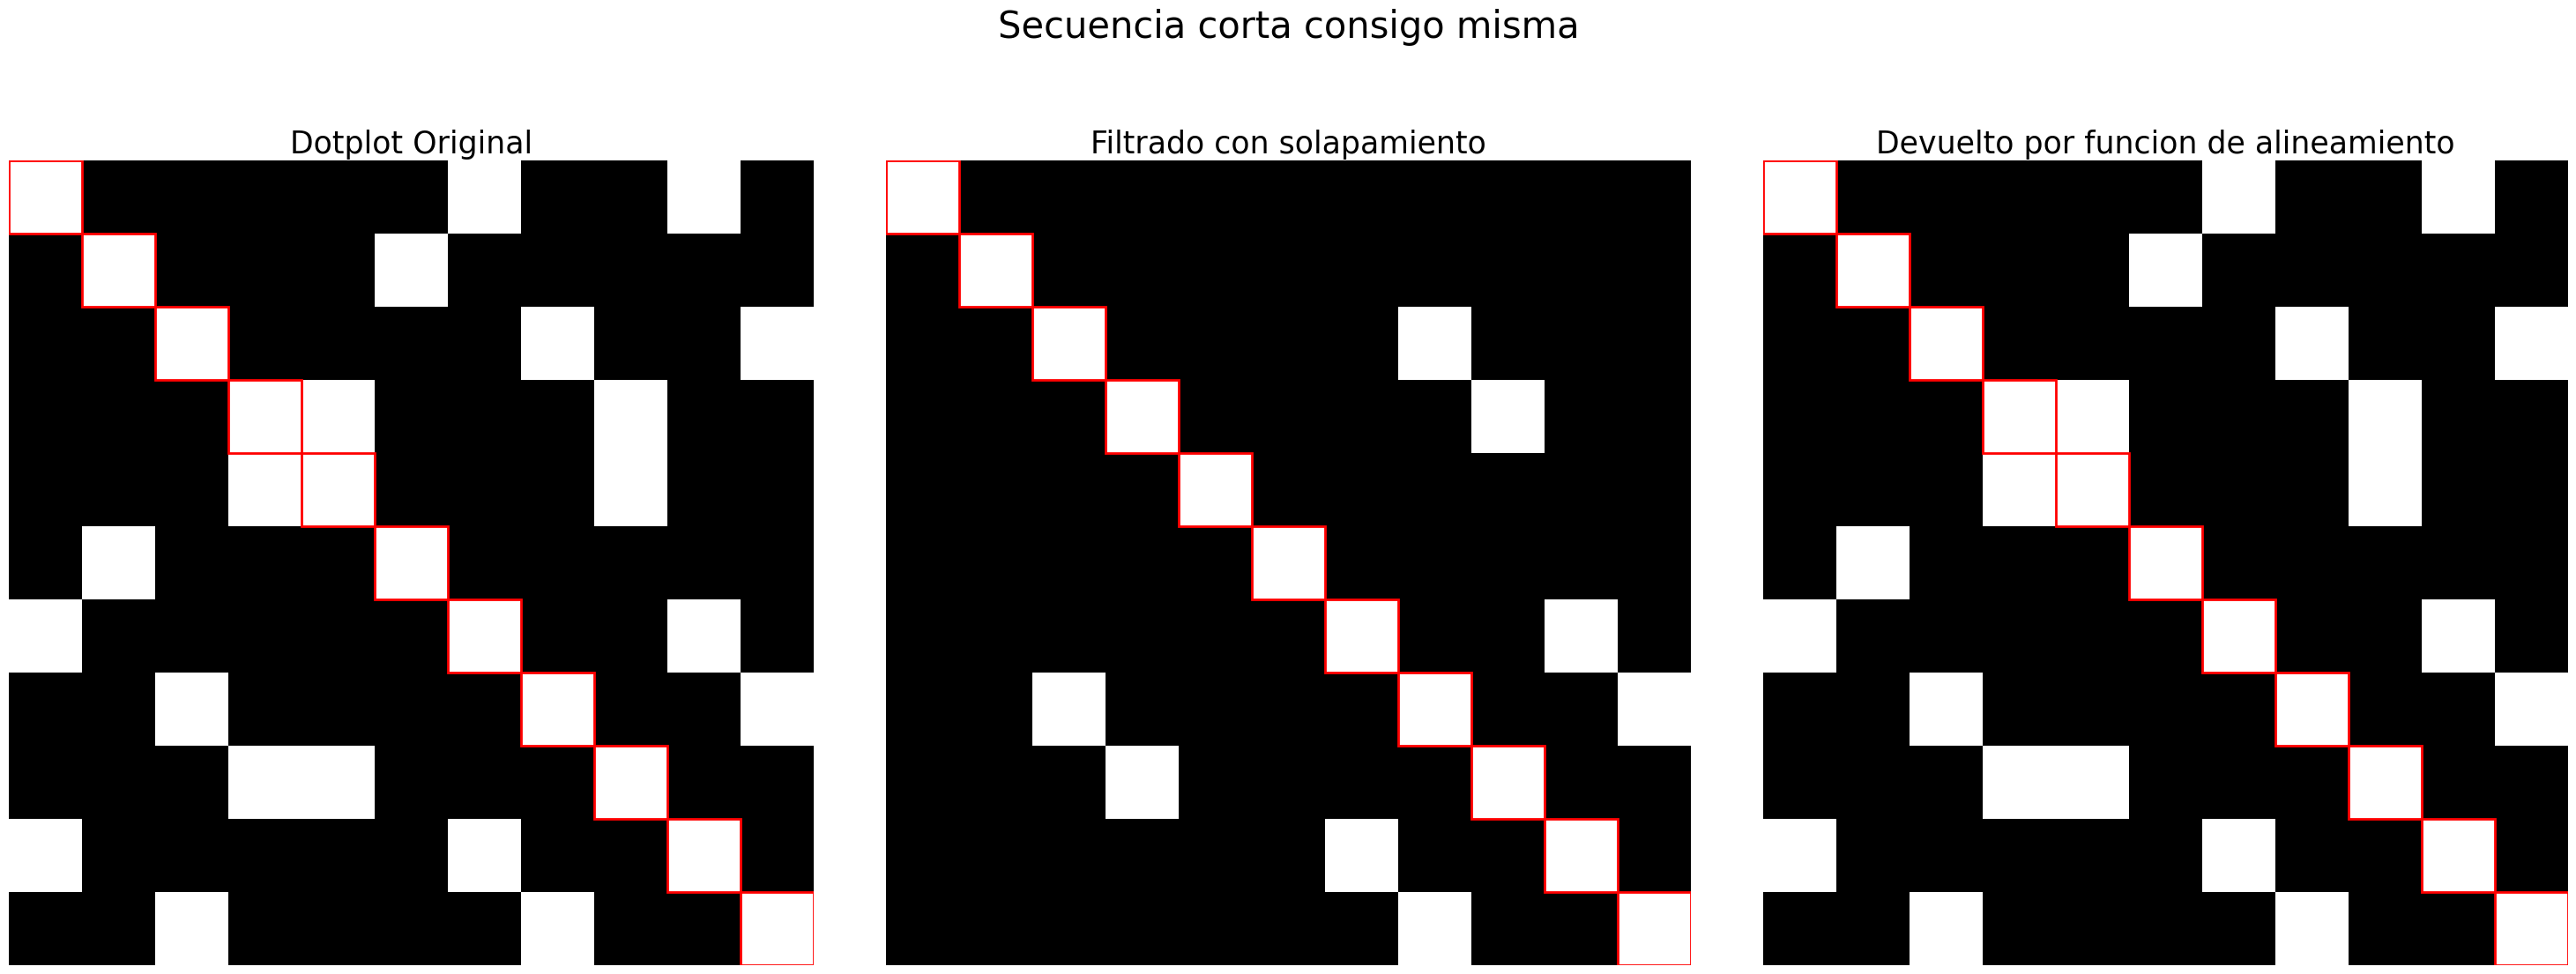

Score: 70 con alineamiento sin filtrar
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA
**********************************************************************

Score: 70 con alineamiento con dotplot filtrado por solapamiento
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA
**********************************************************************

TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA
  Score=70

con alineamiento de funcion pairwise2.align.globalms 


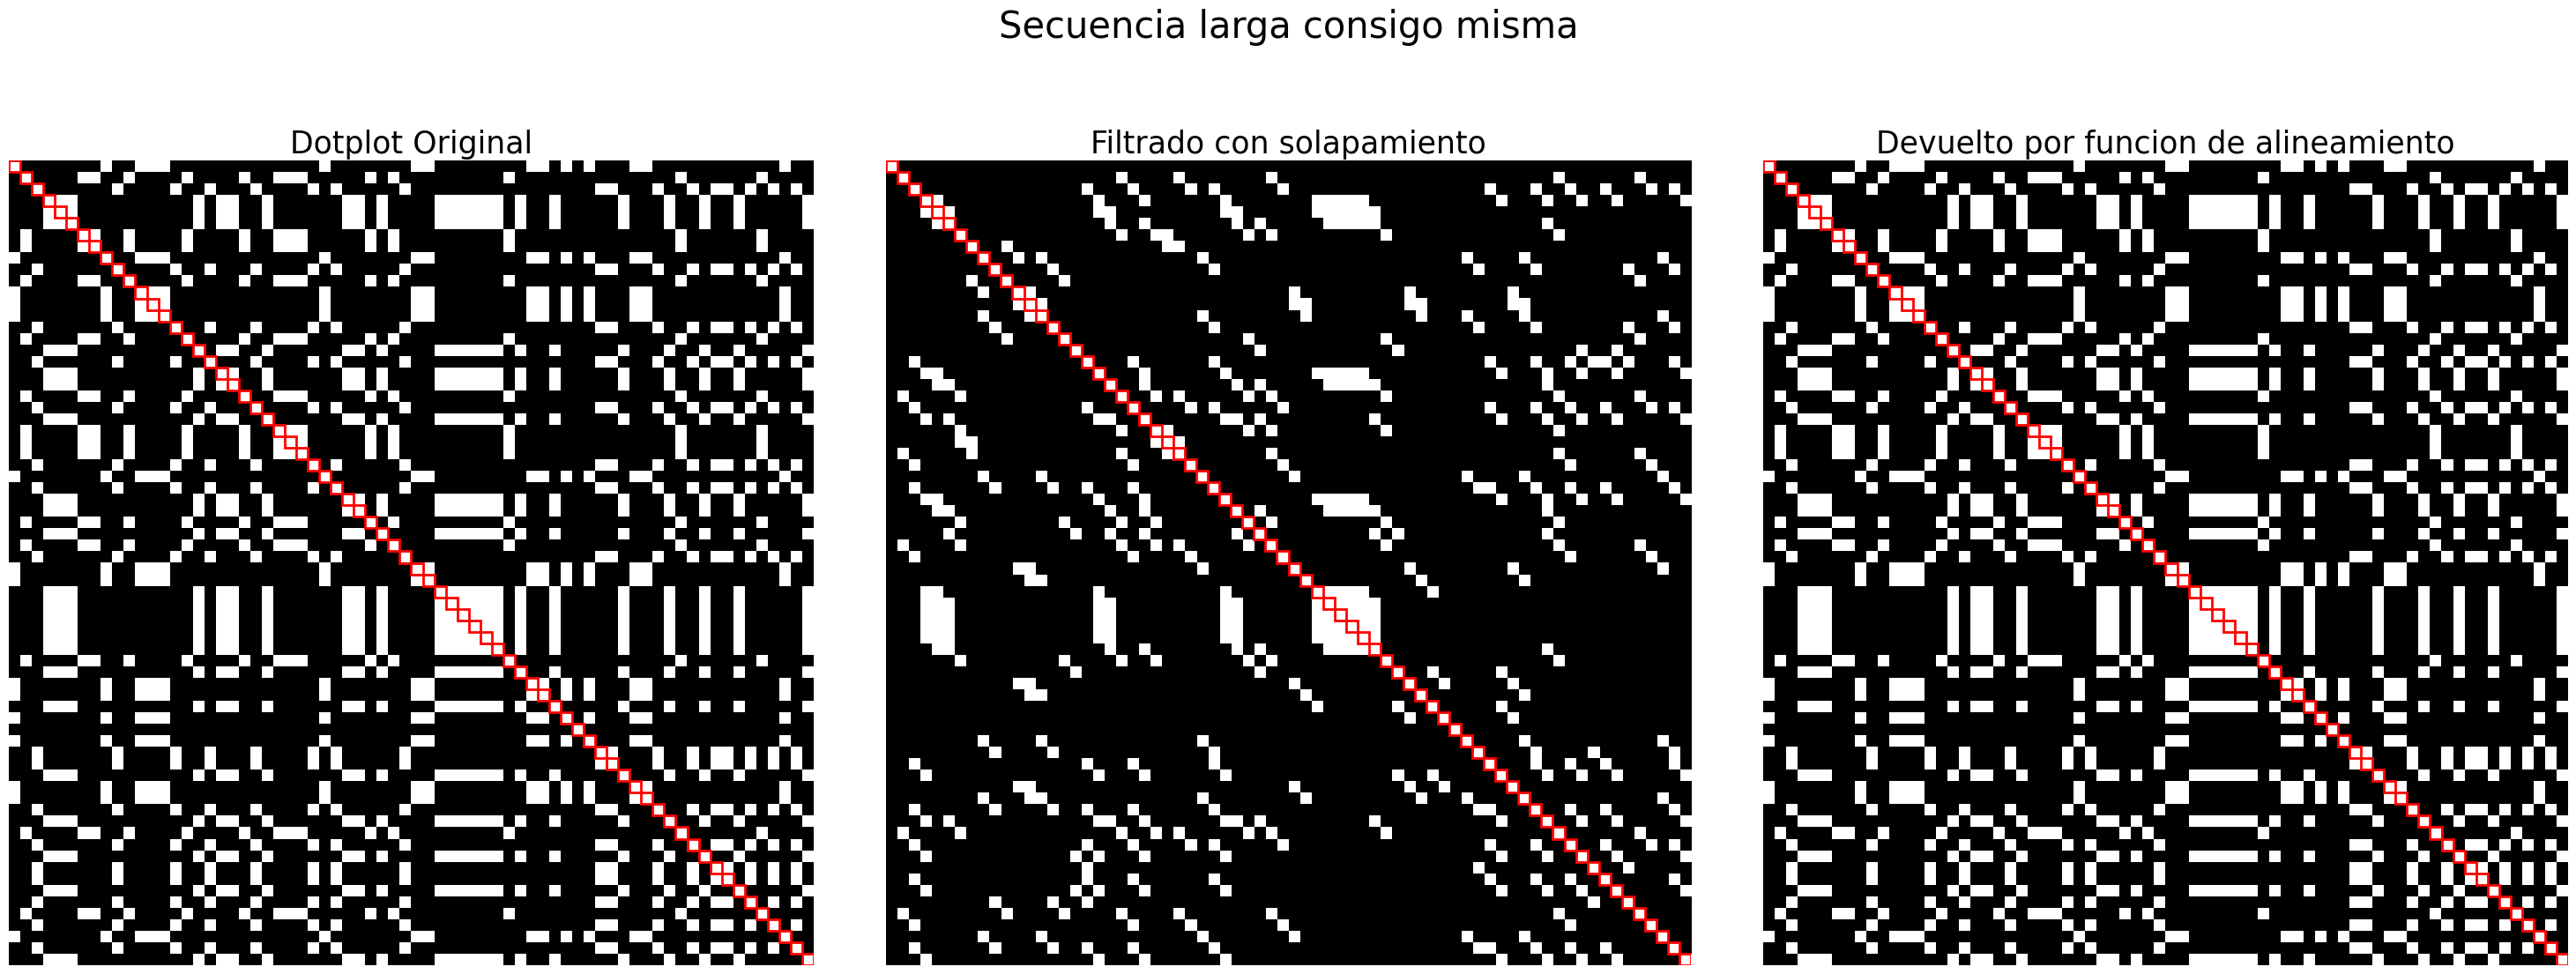

Score: 144 con alineamiento sin filtrar
ATGCGTACGTTAGCCTAGGCTTACGATCGATGCTAGCTAGCTATCGATCGATGCTAGCTGATCGATGCGTATCGTAGCTAGCTGATCGATCGATCGATGCTAGCTAGCGTACGATCGATCGATCGATGCTAGCTAGCTGATCGA
ATGCGTACGTTAGCCTAGGCTTACGATCGATGCTAGCTAGCTATCGATCGATGCTAGCTGATCGATGCGTATCGTAGCTAGCTGATCGATCGATCGATGCTAGCTAGCGTACGATCGATCGATCGATGCTAGCTAGCTGATCGA
************************************************************************************************************************************************

Score: 144 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTTAGCCTAGGCTTACGATCGATGCTAGCTAGCTATCGATCGATGCTAGCTGATCGATGCGTATCGTAGCTAGCTGATCGATCGATCGATGCTAGCTAGCGTACGATCGATCGATCGATGCTAGCTAGCTGATCGA
ATGCGTACGTTAGCCTAGGCTTACGATCGATGCTAGCTAGCTATCGATCGATGCTAGCTGATCGATGCGTATCGTAGCTAGCTGATCGATCGATCGATGCTAGCTAGCGTACGATCGATCGATCGATGCTAGCTAGCTGATCGA
************************************************************************************************************************************************

ATGCGTACGTTAGCCTAGGCTT

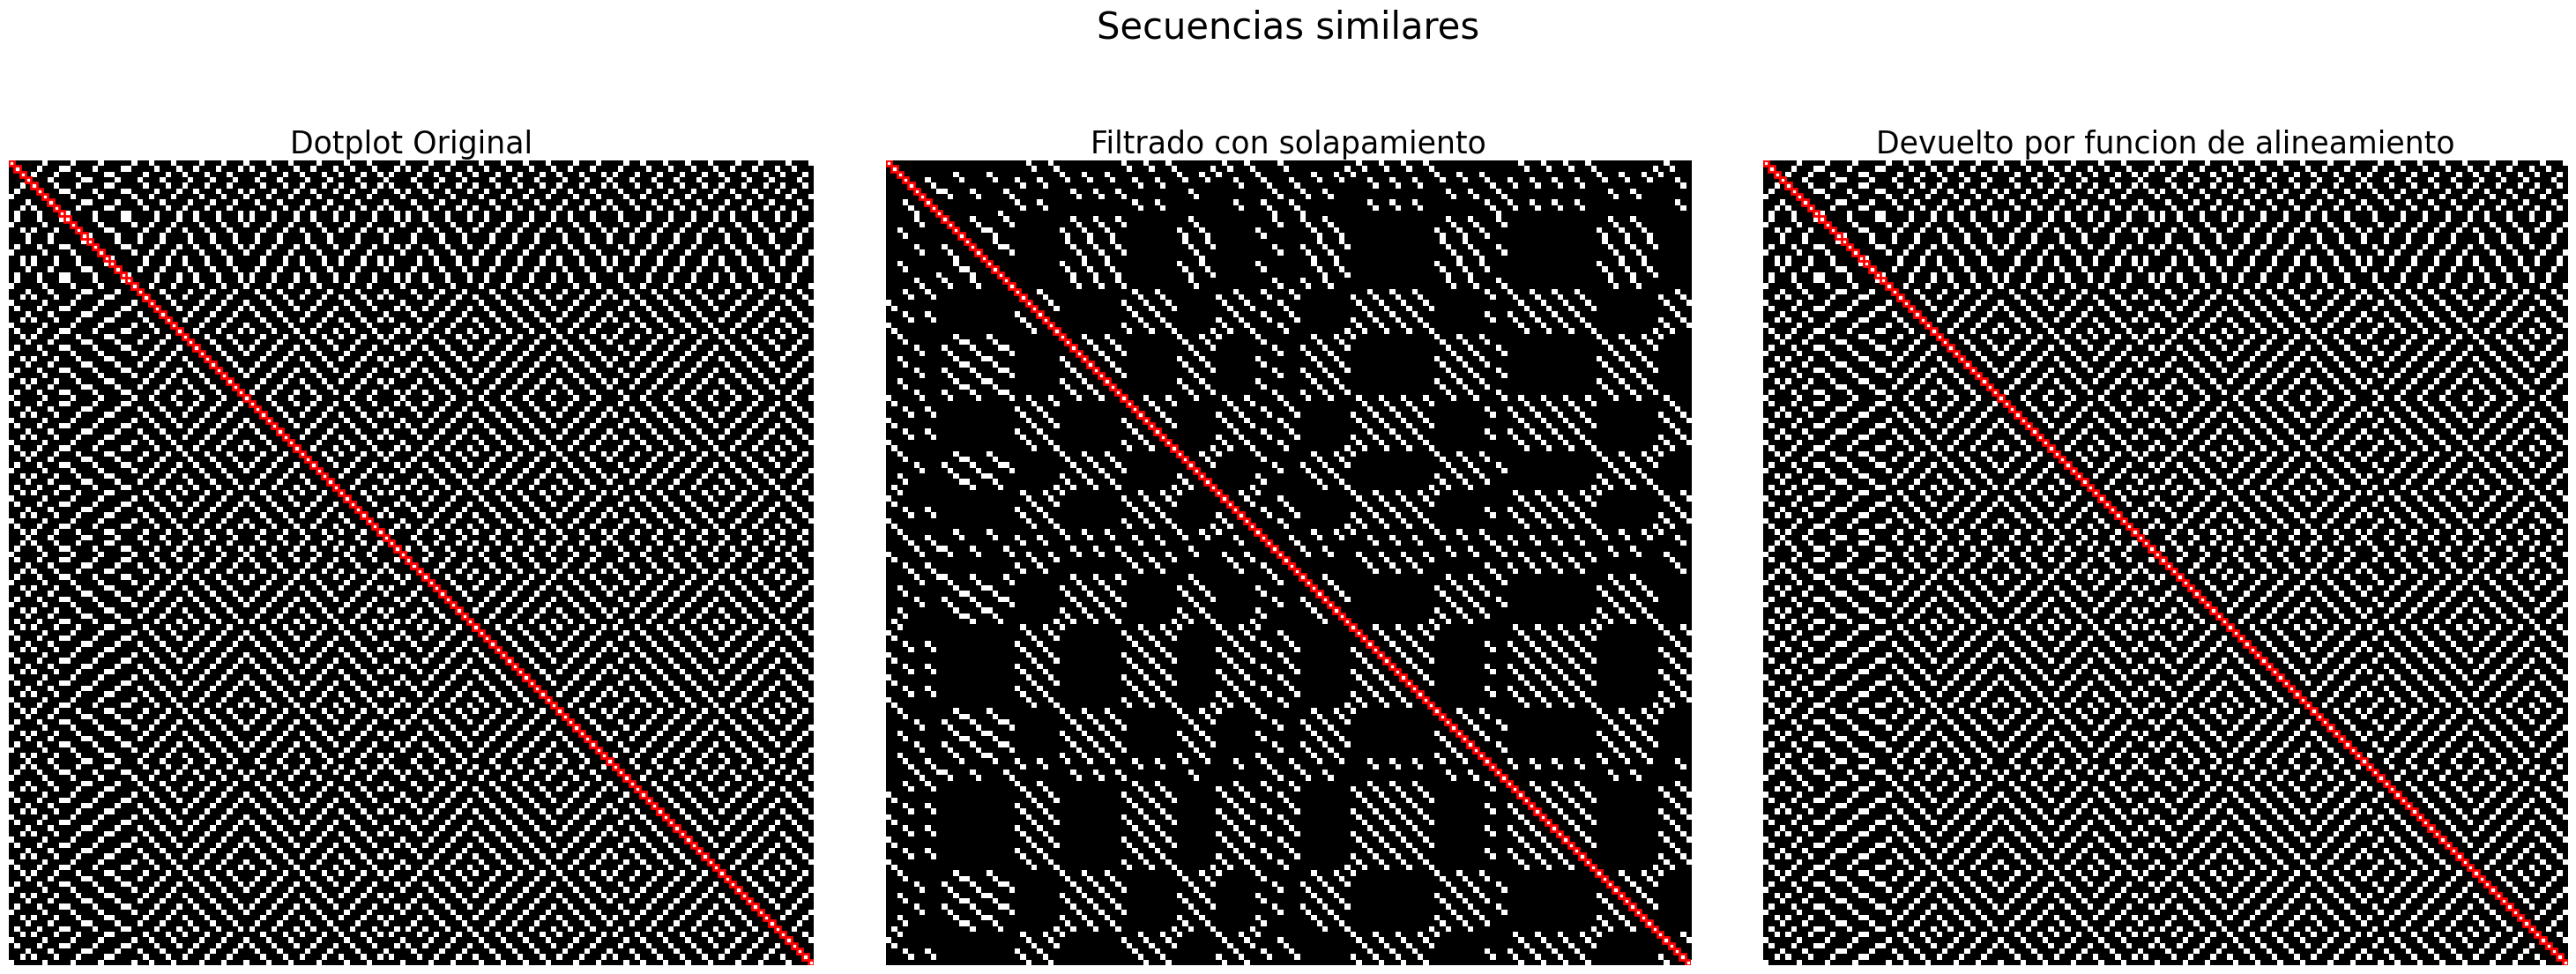

In [53]:
seq1 = "ACGTTCAGTAG"
evaluar_alineamientos(seq1, seq1, "Secuencia corta consigo misma",MATCH, MISMATCH, GAP_OPEN, GAP_EXT)
seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
evaluar_alineamientos(seq1, seq1, "Secuencia larga consigo misma",MATCH, MISMATCH, GAP_OPEN, GAP_EXT)
seq1 ='ATGCGTACGTTAGCCTAGGCTTACGATCGATGCTAGCTAGCTATCGATCGATGCTAGCTGATCGATGCGTATCGTAGCTAGCTGATCGATCGATCGATGCTAGCTAGCGTACGATCGATCGATCGATGCTAGCTAGCTGATCGA'
evaluar_alineamientos(seq1, seq1, "Secuencias similares",MATCH, MISMATCH, GAP_OPEN, GAP_EXT)


## Ahora vamos a comparar secuencias cortas (50 nucleotidos) con alto, medio y bajo grado de identidad

Alto grado identidad

Score: 47 con alineamiento sin filtrar
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT
ATGCGTACGTAGCTAGCTACGATCGTACACTAGCTAGCTAGCTAGCGT
**************************** *******************

Score: 47 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT
ATGCGTACGTAGCTAGCTACGATCGTACACTAGCTAGCTAGCTAGCGT
**************************** *******************

ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT
||||||||||||||||||||||||||||.|||||||||||||||||||
ATGCGTACGTAGCTAGCTACGATCGTACACTAGCTAGCTAGCTAGCGT
  Score=47

con alineamiento de funcion pairwise2.align.globalms 


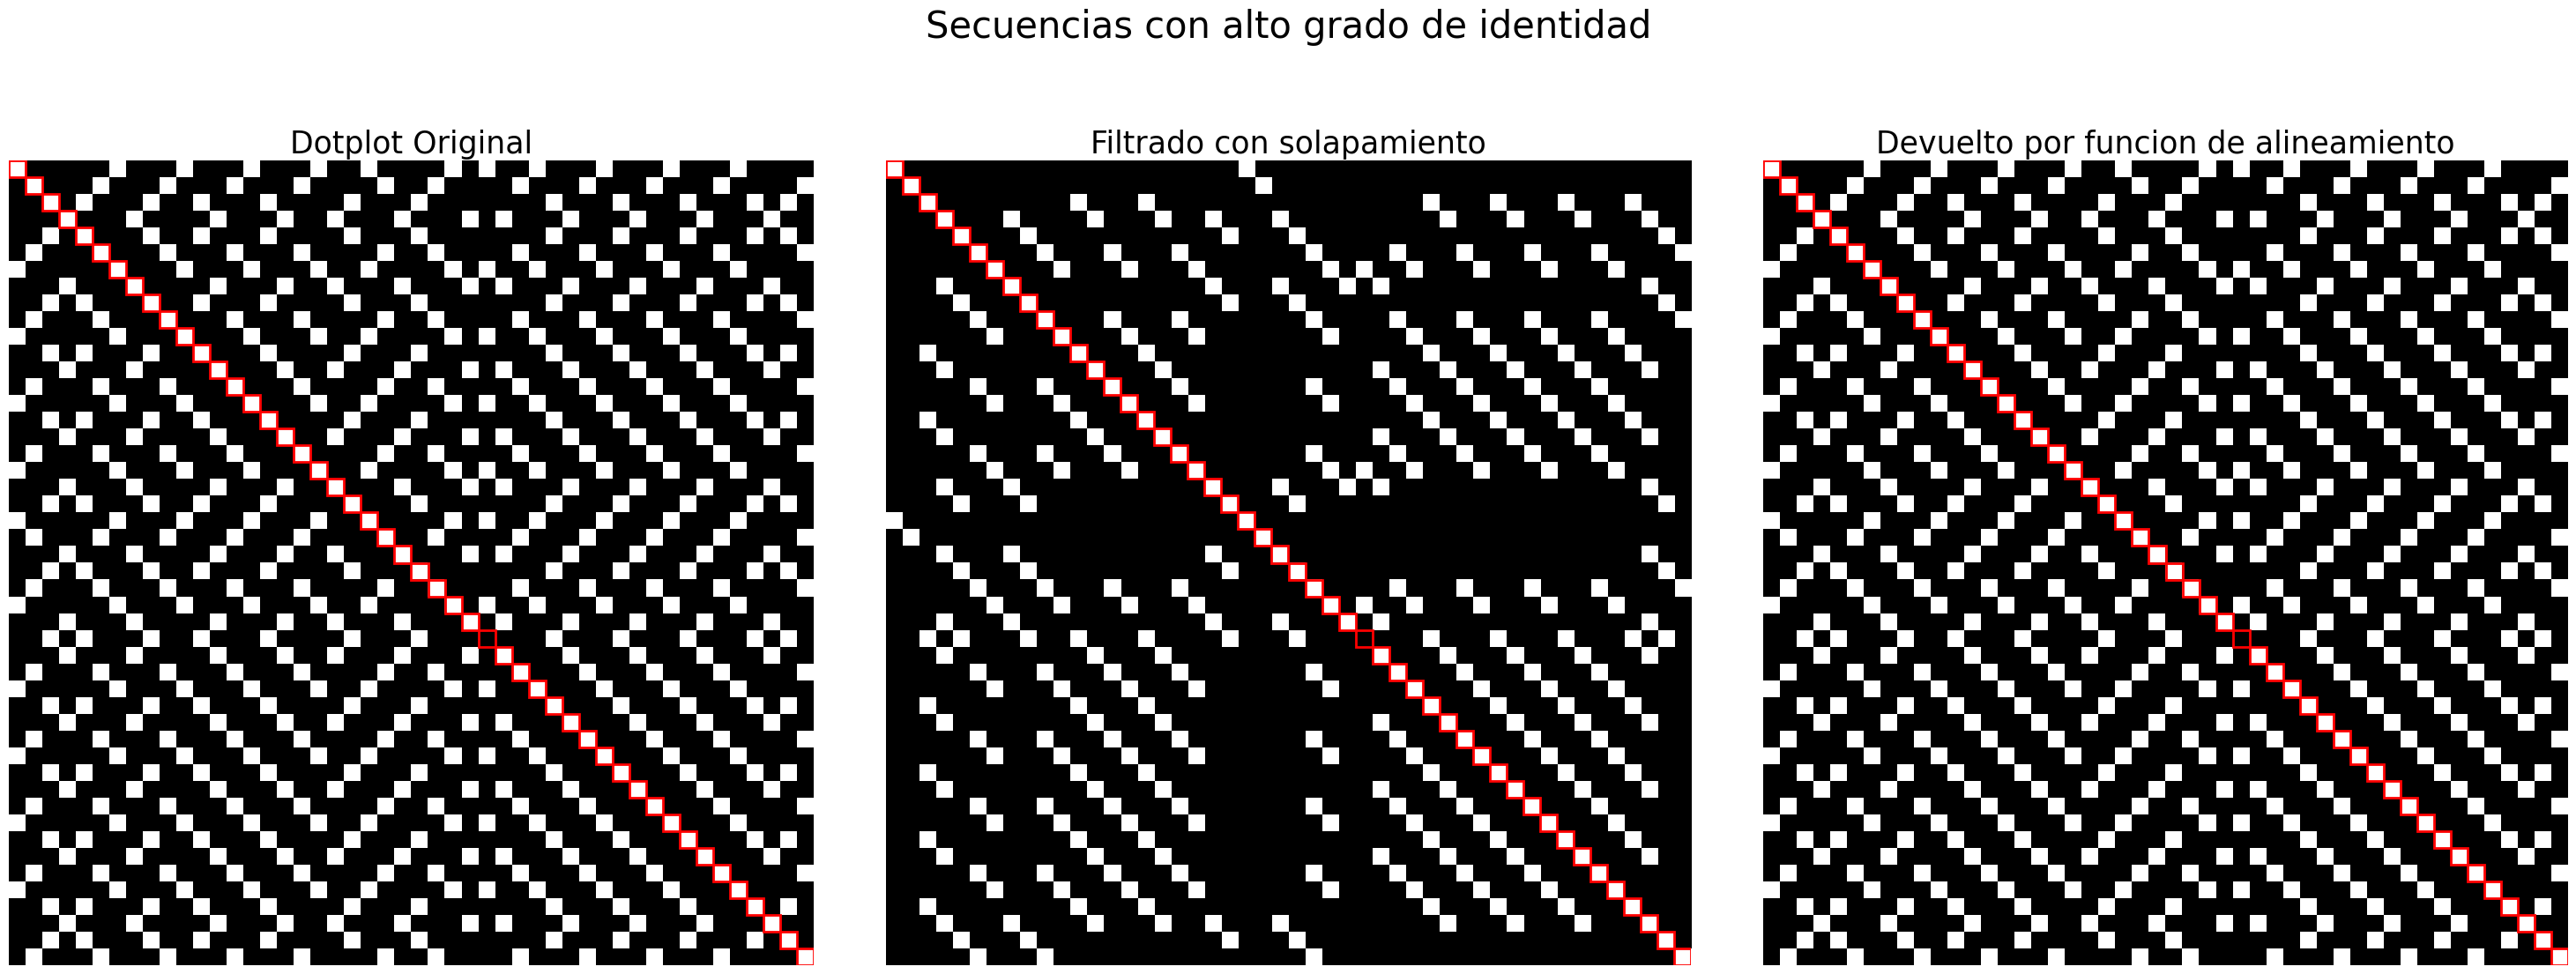

In [54]:
seq1 = "ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT"
                                    #
seq2 = "ATGCGTACGTAGCTAGCTACGATCGTACACTAGCTAGCTAGCTAGCGT"
evaluar_alineamientos(seq1, seq2, "Secuencias con alto grado de identidad", MATCH, MISMATCH, GAP_OPEN, GAP_EXT)


Medio grado de identidad

Score: 15 con alineamiento sin filtrar
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAG-CGT
GTACGTTAGGCTCGATAGCTGATCGGACGTAG-TTCGATCTGCAAGCTT
 * ***  *   * *     ***** ***     * * *    *  * *

Score: 21 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT
GTACGTTAGGCTCGATAGCTGATCGGACGTAGTTCGATCTGCAAGCTT
 * ***  *   * *     ***** ***           ** *** *

ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTA-GCTAGCGT
.|.|||..|...|.|.....|||||.||| |||.|.|.|. ||.|||.|
GTACGTTAGGCTCGATAGCTGATCGGACG-TAGTTCGATCTGCAAGCTT
  Score=21

con alineamiento de funcion pairwise2.align.globalms 


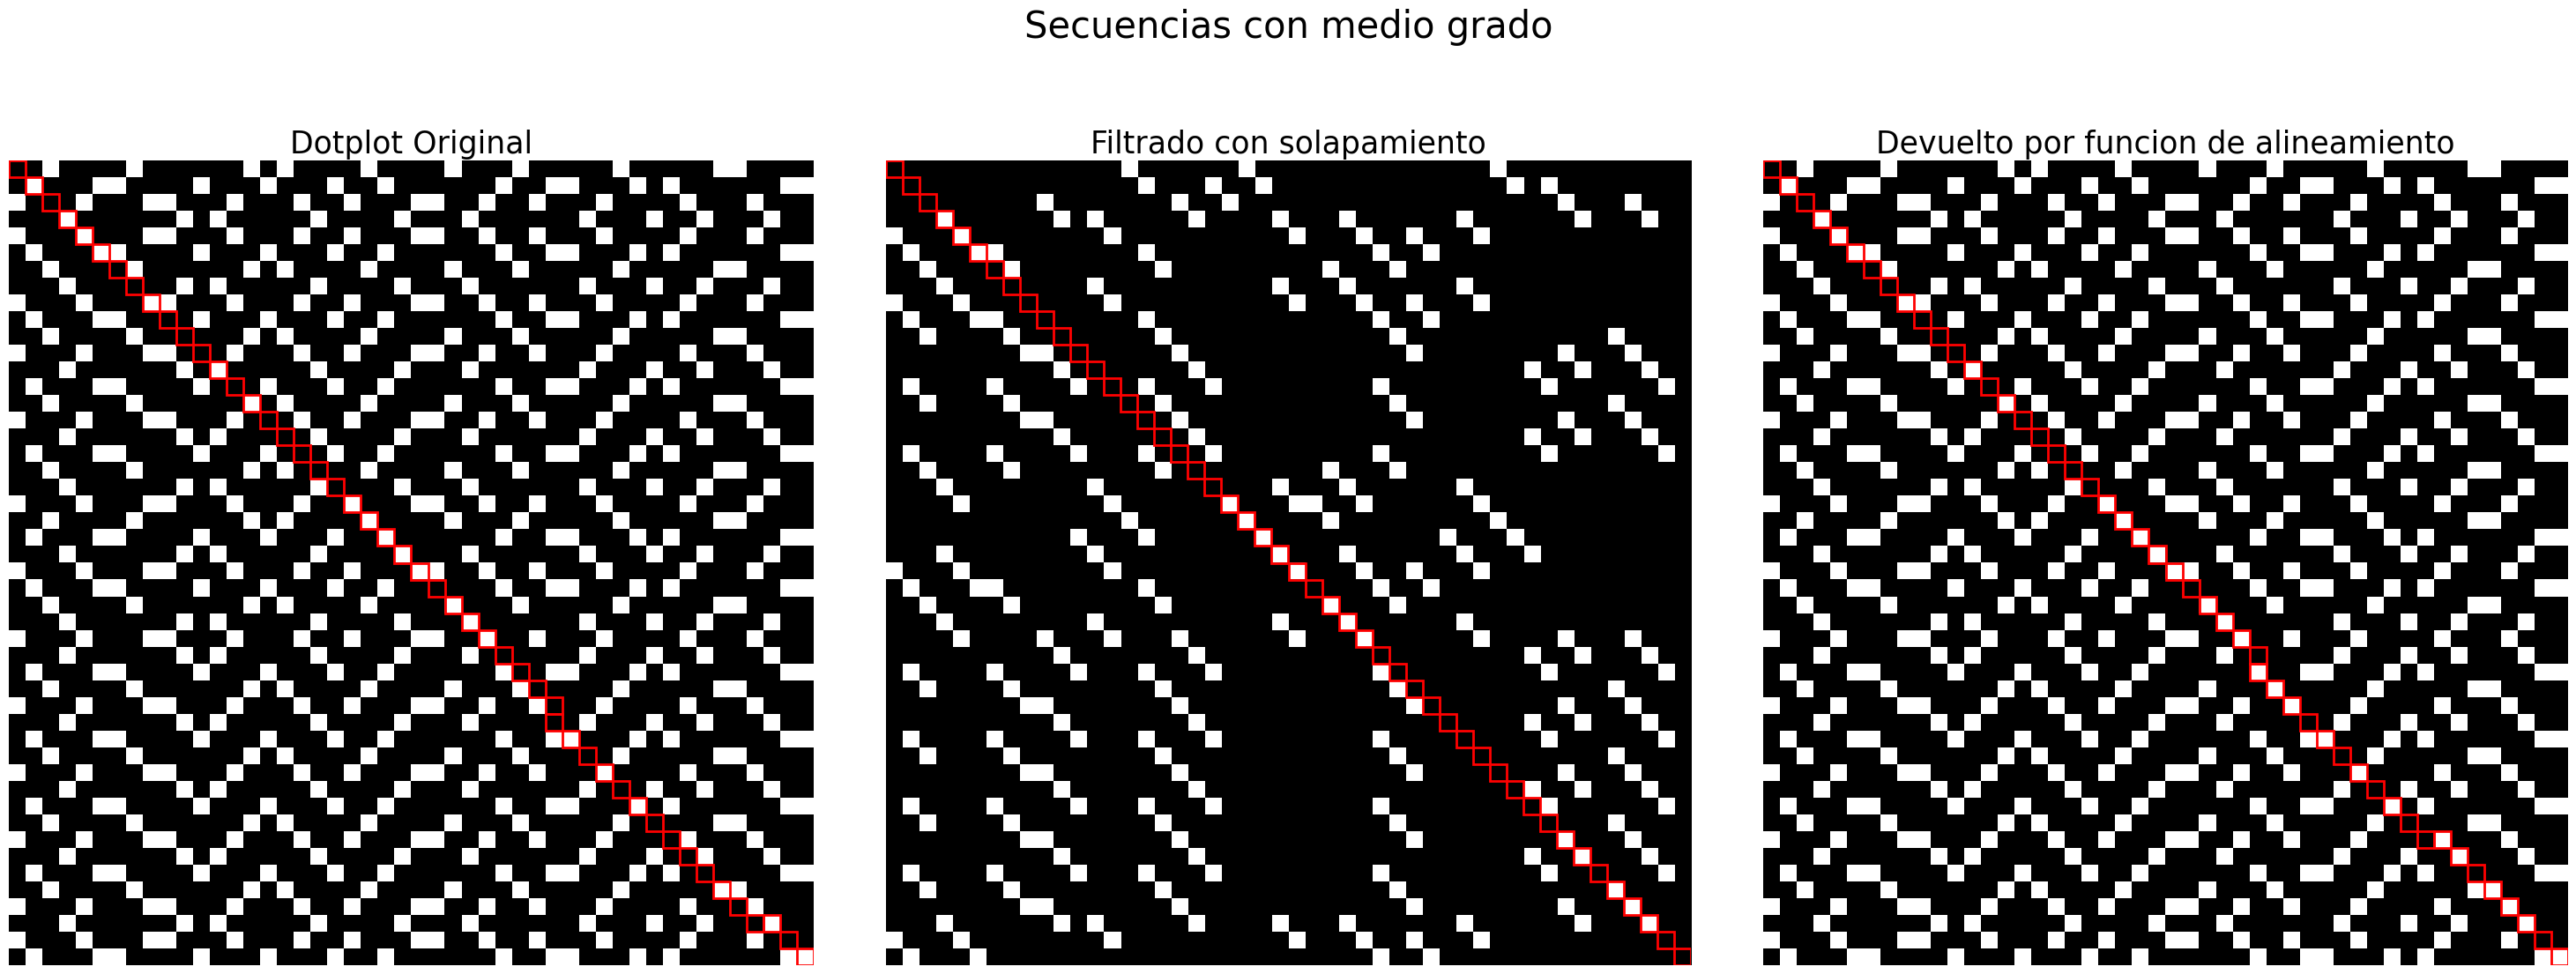

In [55]:
seq1 = "ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT"
seq2 = "GTACGTTAGGCTCGATAGCTGATCGGACGTAGTTCGATCTGCAAGCTT"
evaluar_alineamientos(seq1, seq2, "Secuencias con medio grado", MATCH, MISMATCH, GAP_OPEN, GAP_EXT)

Bajo grado de identidad

Score: 6 con alineamiento sin filtrar
ATGCGTACGTAGCTAGCTACGATCGTACGCTAG--CTAGCTAGCTAGCGT
CAGTTAACCGGTTAAC-TGCGGAGTCACCTTGAAGCTTGGGACCAATGT-
  *   **      *  * **     **  *    ** *  * * *    

Score: 7 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTAGCTAGCTACGATCGTACGCTA--GCTAGCTAGCTAGCGT
CAGTTAACCGGTTAAC-TGCGGAGTCACCTTGAAGCTTGGGACCAATGT-
  *   **      *  * **     **  *   *** *  * * *    

ATGCGTACGTAGCTAGCTACGATCGTACGCT--AGCTAGCTAGCTAGCGT
..| .||....|.||.||.||.....||..|  ||||.|..| |.|..||
CAG-TTAACCGGTTAACTGCGGAGTCACCTTGAAGCTTGGGA-CCAATGT
  Score=13

con alineamiento de funcion pairwise2.align.globalms 


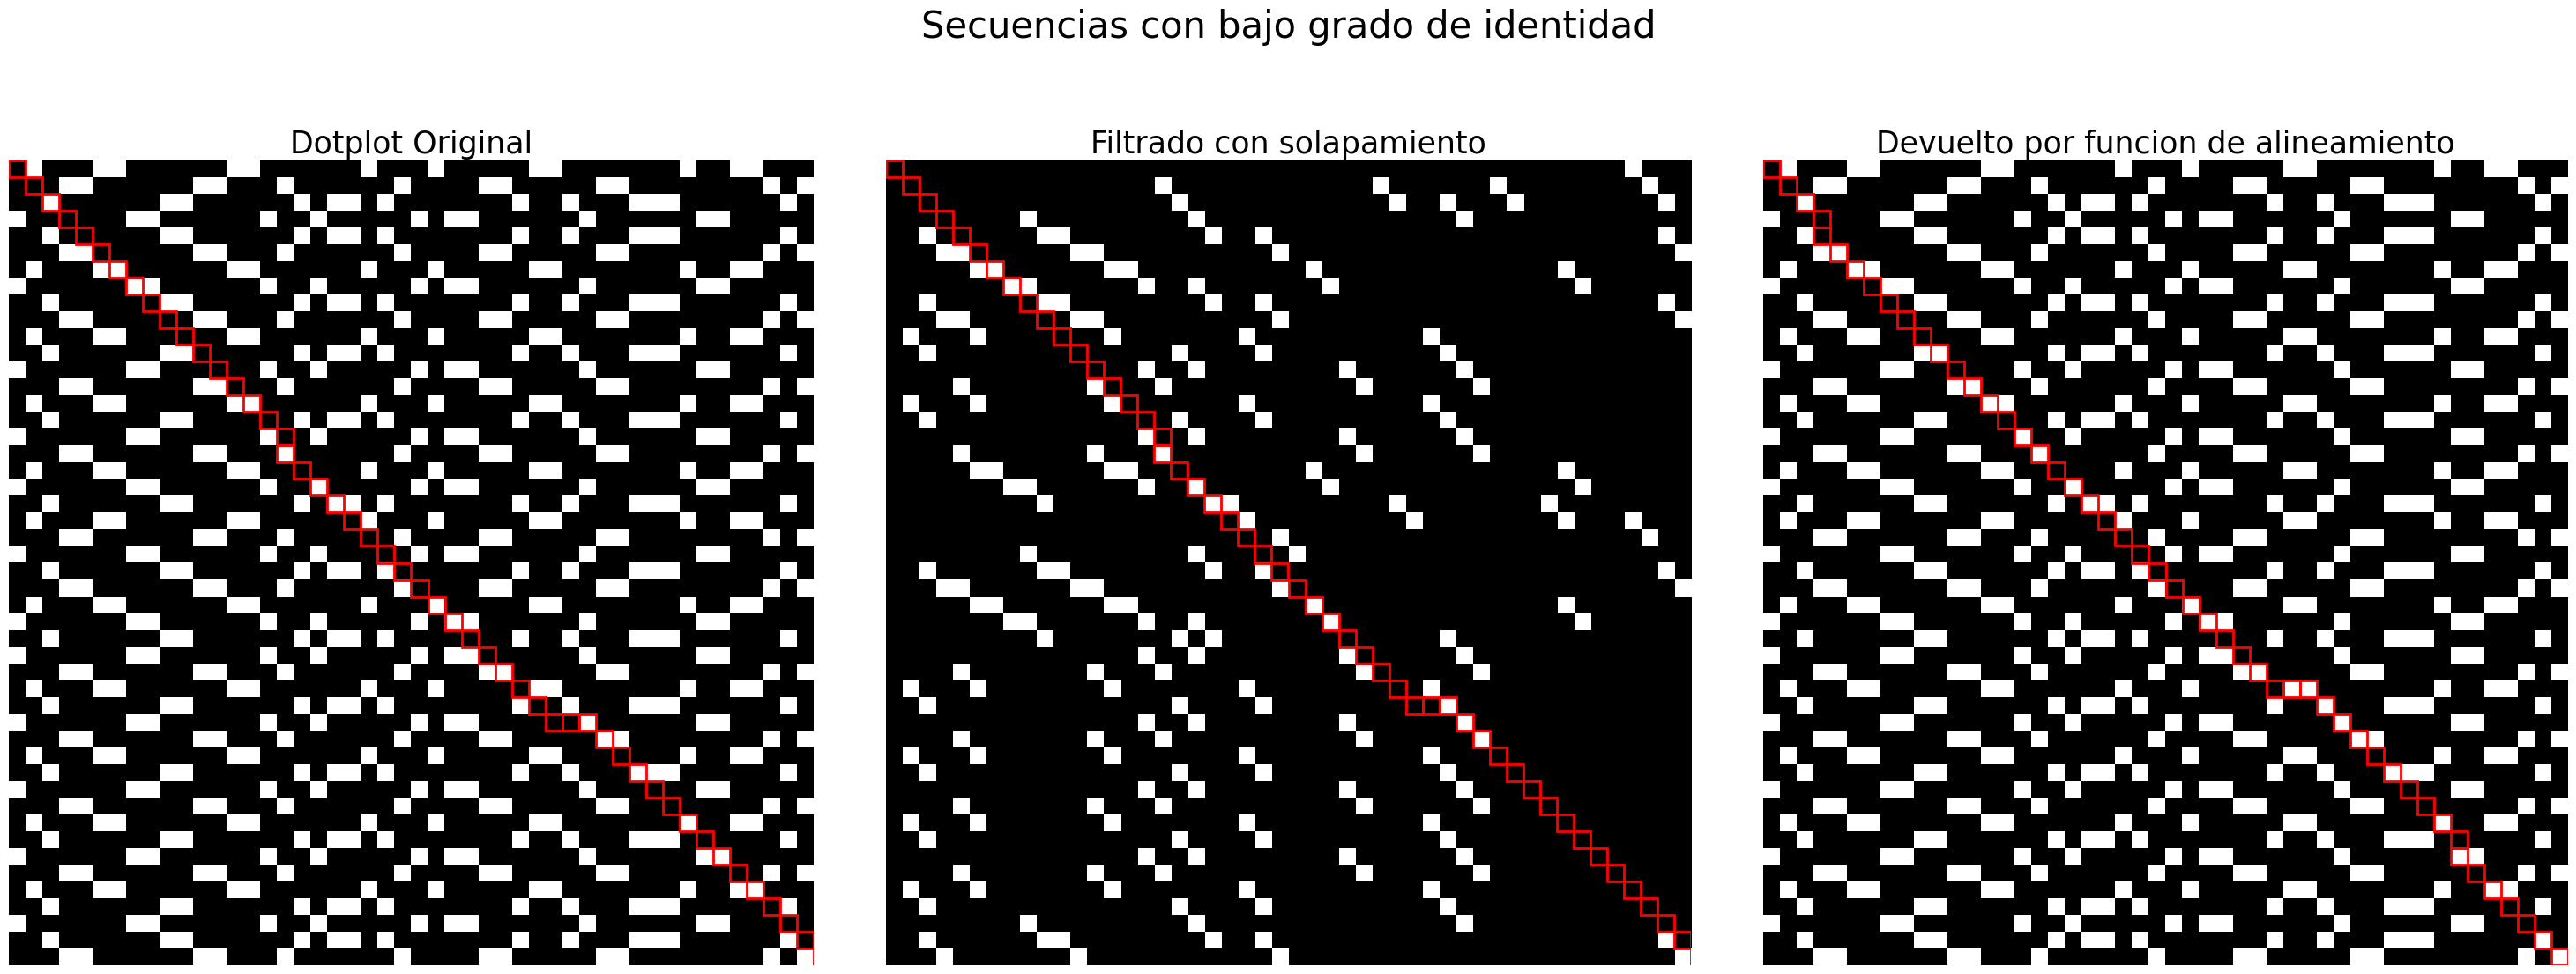

In [56]:
seq1 = "ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGT"
seq2 = "CAGTTAACCGGTTAACTGCGGAGTCACCTTGAAGCTTGGGACCAATGT"
evaluar_alineamientos(seq1, seq2, "Secuencias con bajo grado de identidad", MATCH, MISMATCH, GAP_OPEN, GAP_EXT)


## Comparamos secuencias  con alto, medio y bajo grado de identidad; donde una de ellas tiene 50 nucletoidos y la otra 100.


Alto grado de identidad

Score: -3 con alineamiento sin filtrar
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
C-----------------------GTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAG------------------------
                        ************************************************                        

Score: -3 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
C-----------------------GTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAG------------------------
                        ************************************************                        

ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
                       |||||||||||||||||||||||||||||||||||||||||||||||||                        
-----------------------CGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAG------------------------
  Score=-2

con aline

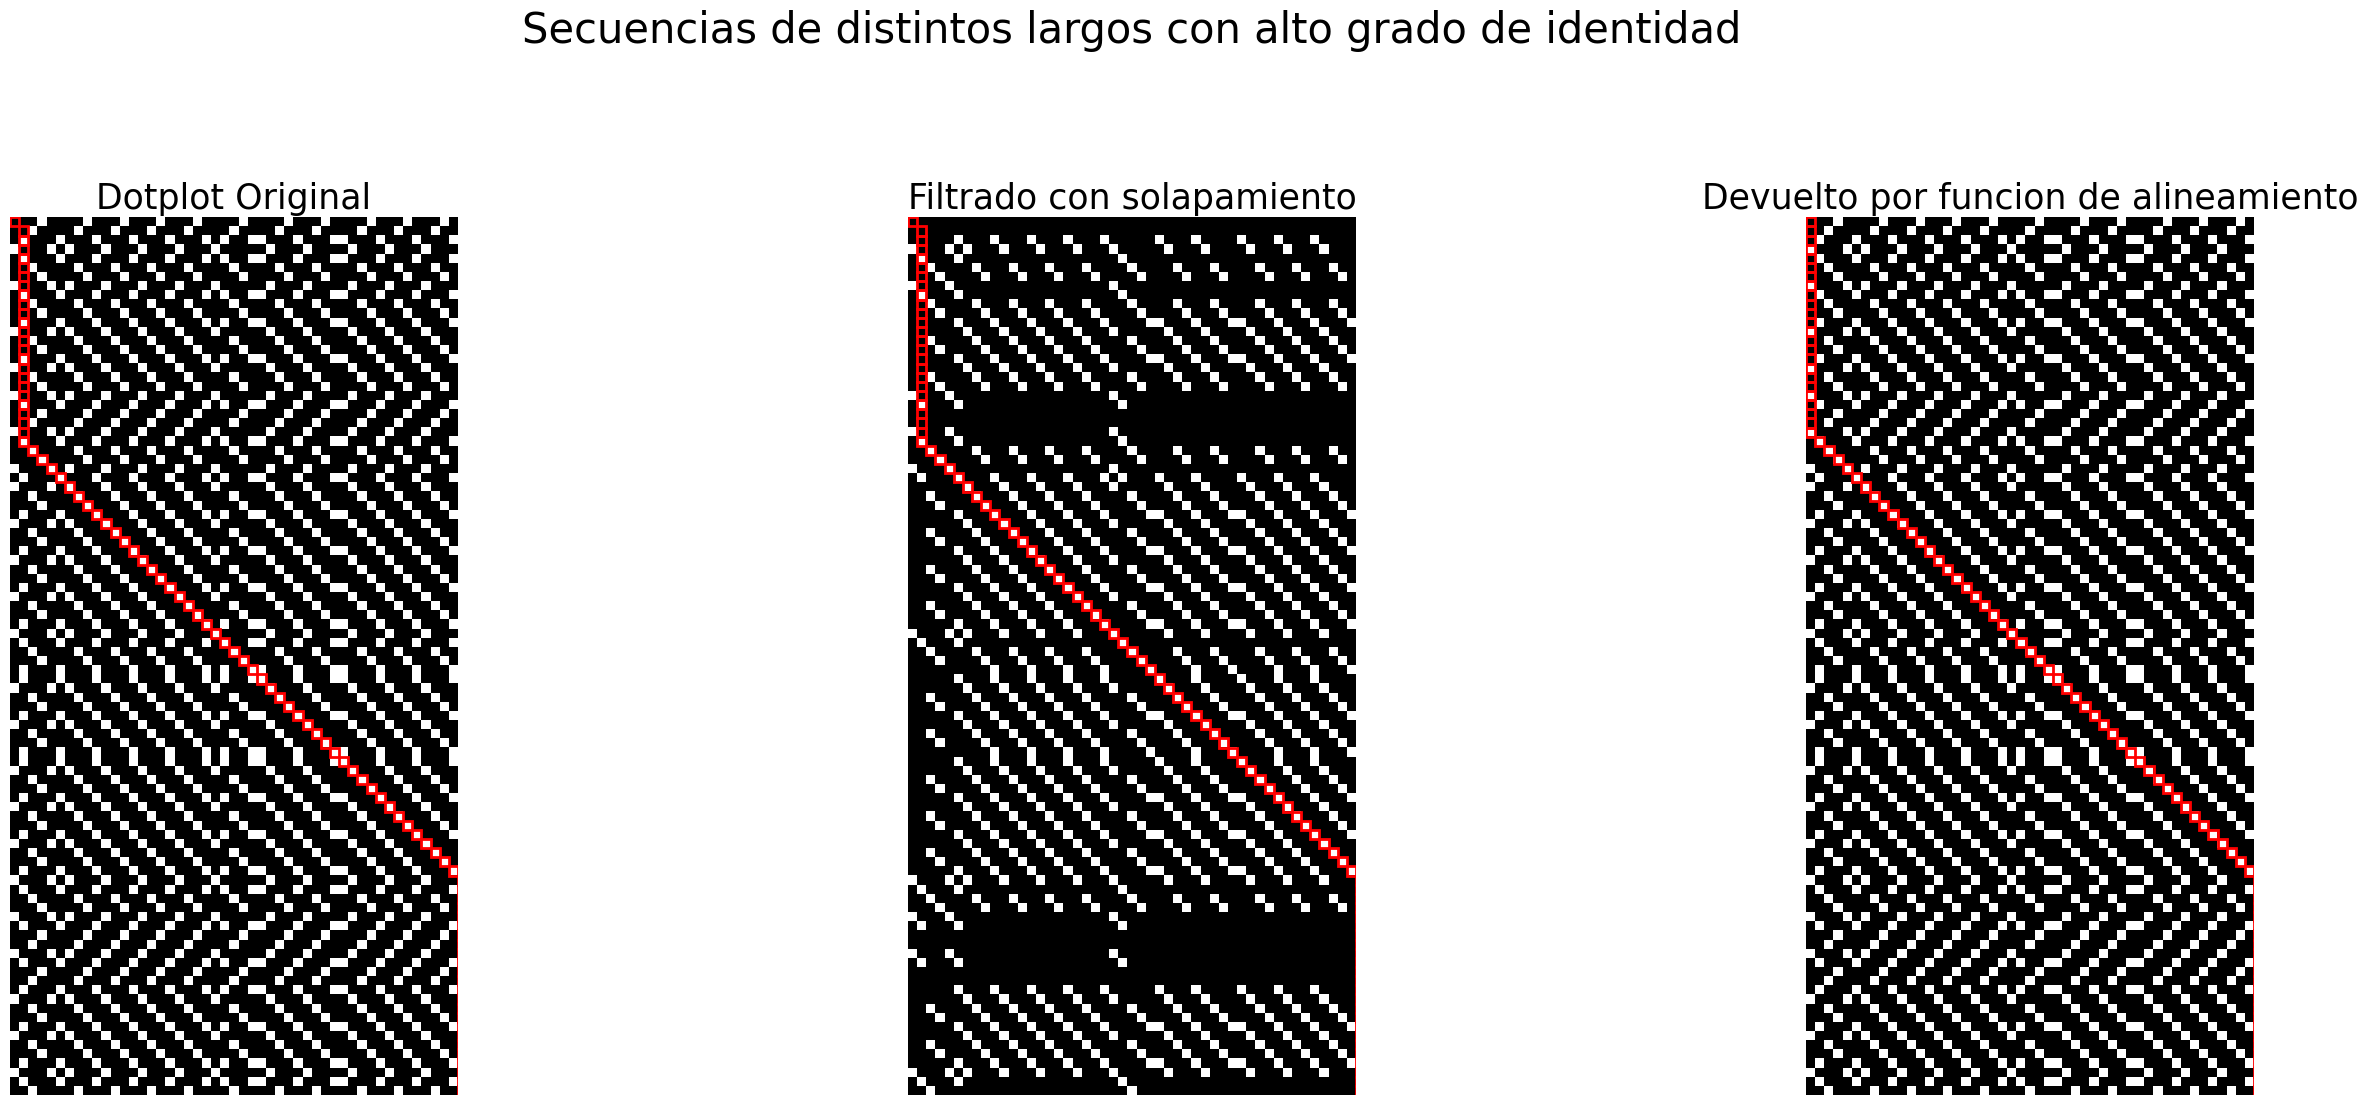

In [57]:
seq1 = "ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT"
seq2 = "CGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAG"
evaluar_alineamientos(seq1,seq2, "Secuencias de distintos largos con alto grado de identidad", MATCH, MISMATCH, GAP_OPEN, GAP_EXT)

Medio grado de identidad

Score: -24 con alineamiento sin filtrar
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
G---------------TTAGGACCTTACGCTAGG---CTAGTTACCTGACGCTT--------ACCTGA---GCGTAT--------------C--GG
                 ** ** * ********    **** ** *  * ***         * **     *****                  * 

Score: -25 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
G--------TT-------AGGACCTTACGCTAGG---CTAGTTACCTGACGCTT--------ACCTGA---GCGTAT---CGG-------------
         *        * ** * ********    **** ** *  * ***         * **     *****    **              

ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
               |.||.||.|.||||||||   |||||.||.|..|.|||        ||.||   .||||                ||.||.
---------------GTTAGGACCTTACGCTAG---GCTAGTTACCTGACGCT--------TACCT---GAGCG----------------TATCGG
  Score=-17

con al

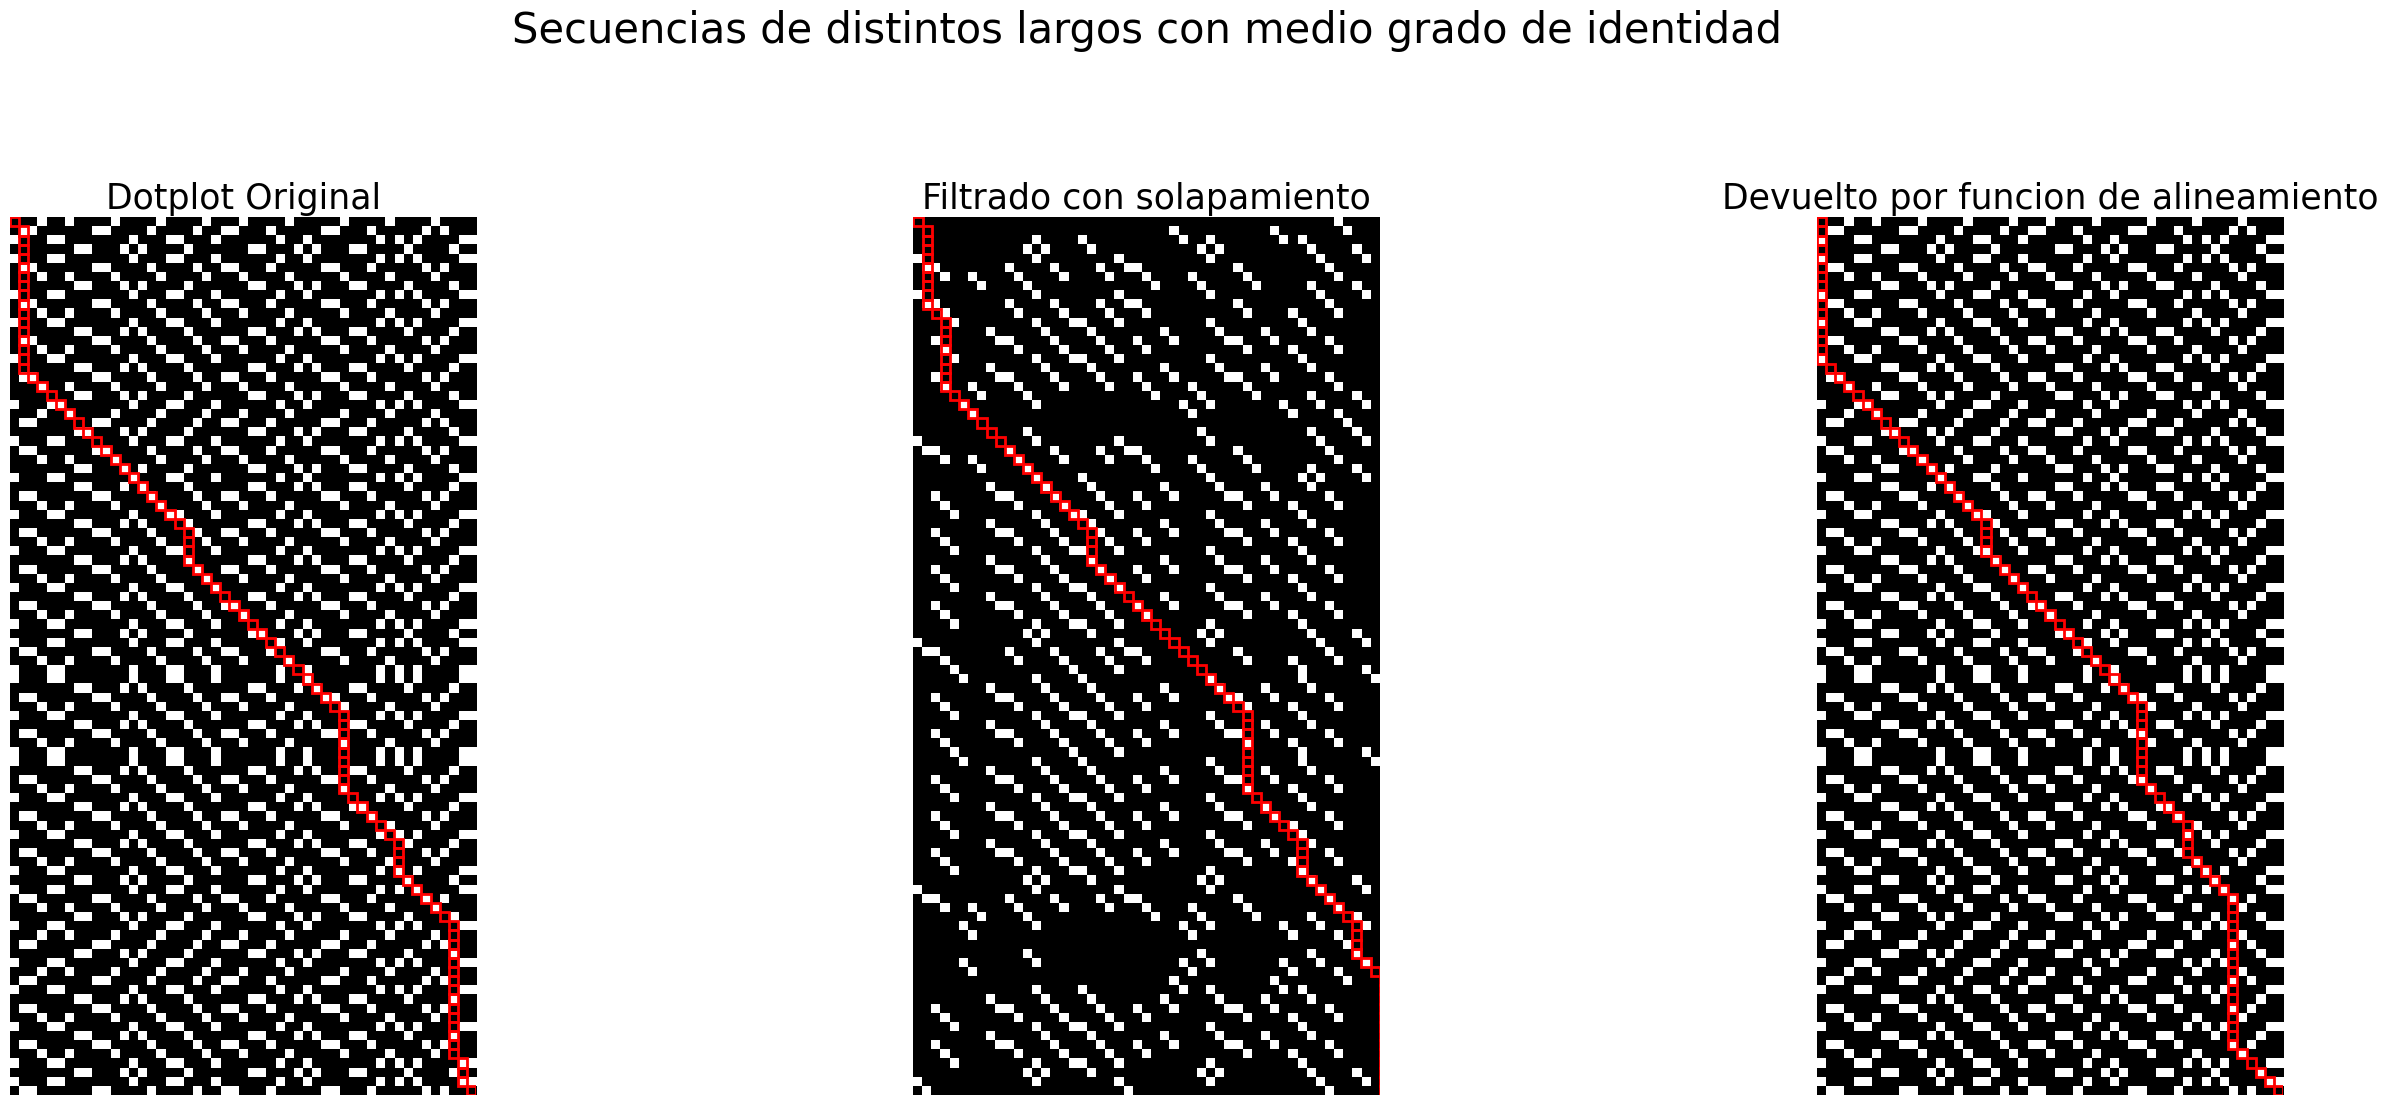

In [58]:
seq1 = "ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT"
seq2 = "GTTAGGACCTTACGCTAGGCTAGTTACCTGACGCTTACCTGAGCGTATCGG"
evaluar_alineamientos(seq1,seq2, "Secuencias de distintos largos con medio grado de identidad", MATCH, MISMATCH, GAP_OPEN, GAP_EXT)

Bajo grado de identidad

Score: -29 con alineamiento sin filtrar
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
TCCGGAACCTTGGGATTAC-GGCCTTACGGG-----------------------------TTAGGAACC----GTT-----------AGGTAGTCC
    * ** * *  *     *  * ****                                ***  * *    **            ** ***   

Score: -30 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
TCCGGAACCTTGGGATTAC-GGCCTTACGG-----------------------------GTTAGGAA---------CC---GTT---AGGTAGTCC
    * ** * *  *     *  * ****                              * ***  *         *    * *   ** ***   

ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT
....|.||.|.|..| .||||..|.||||                             ||.|||..|.|               |.|||.|||...
TCCGGAACCTTGGGA-TTACGGCCTTACG-----------------------------GGTTAGGAACC---------------GTTAGGTAGTCC
  Score=-22

con al

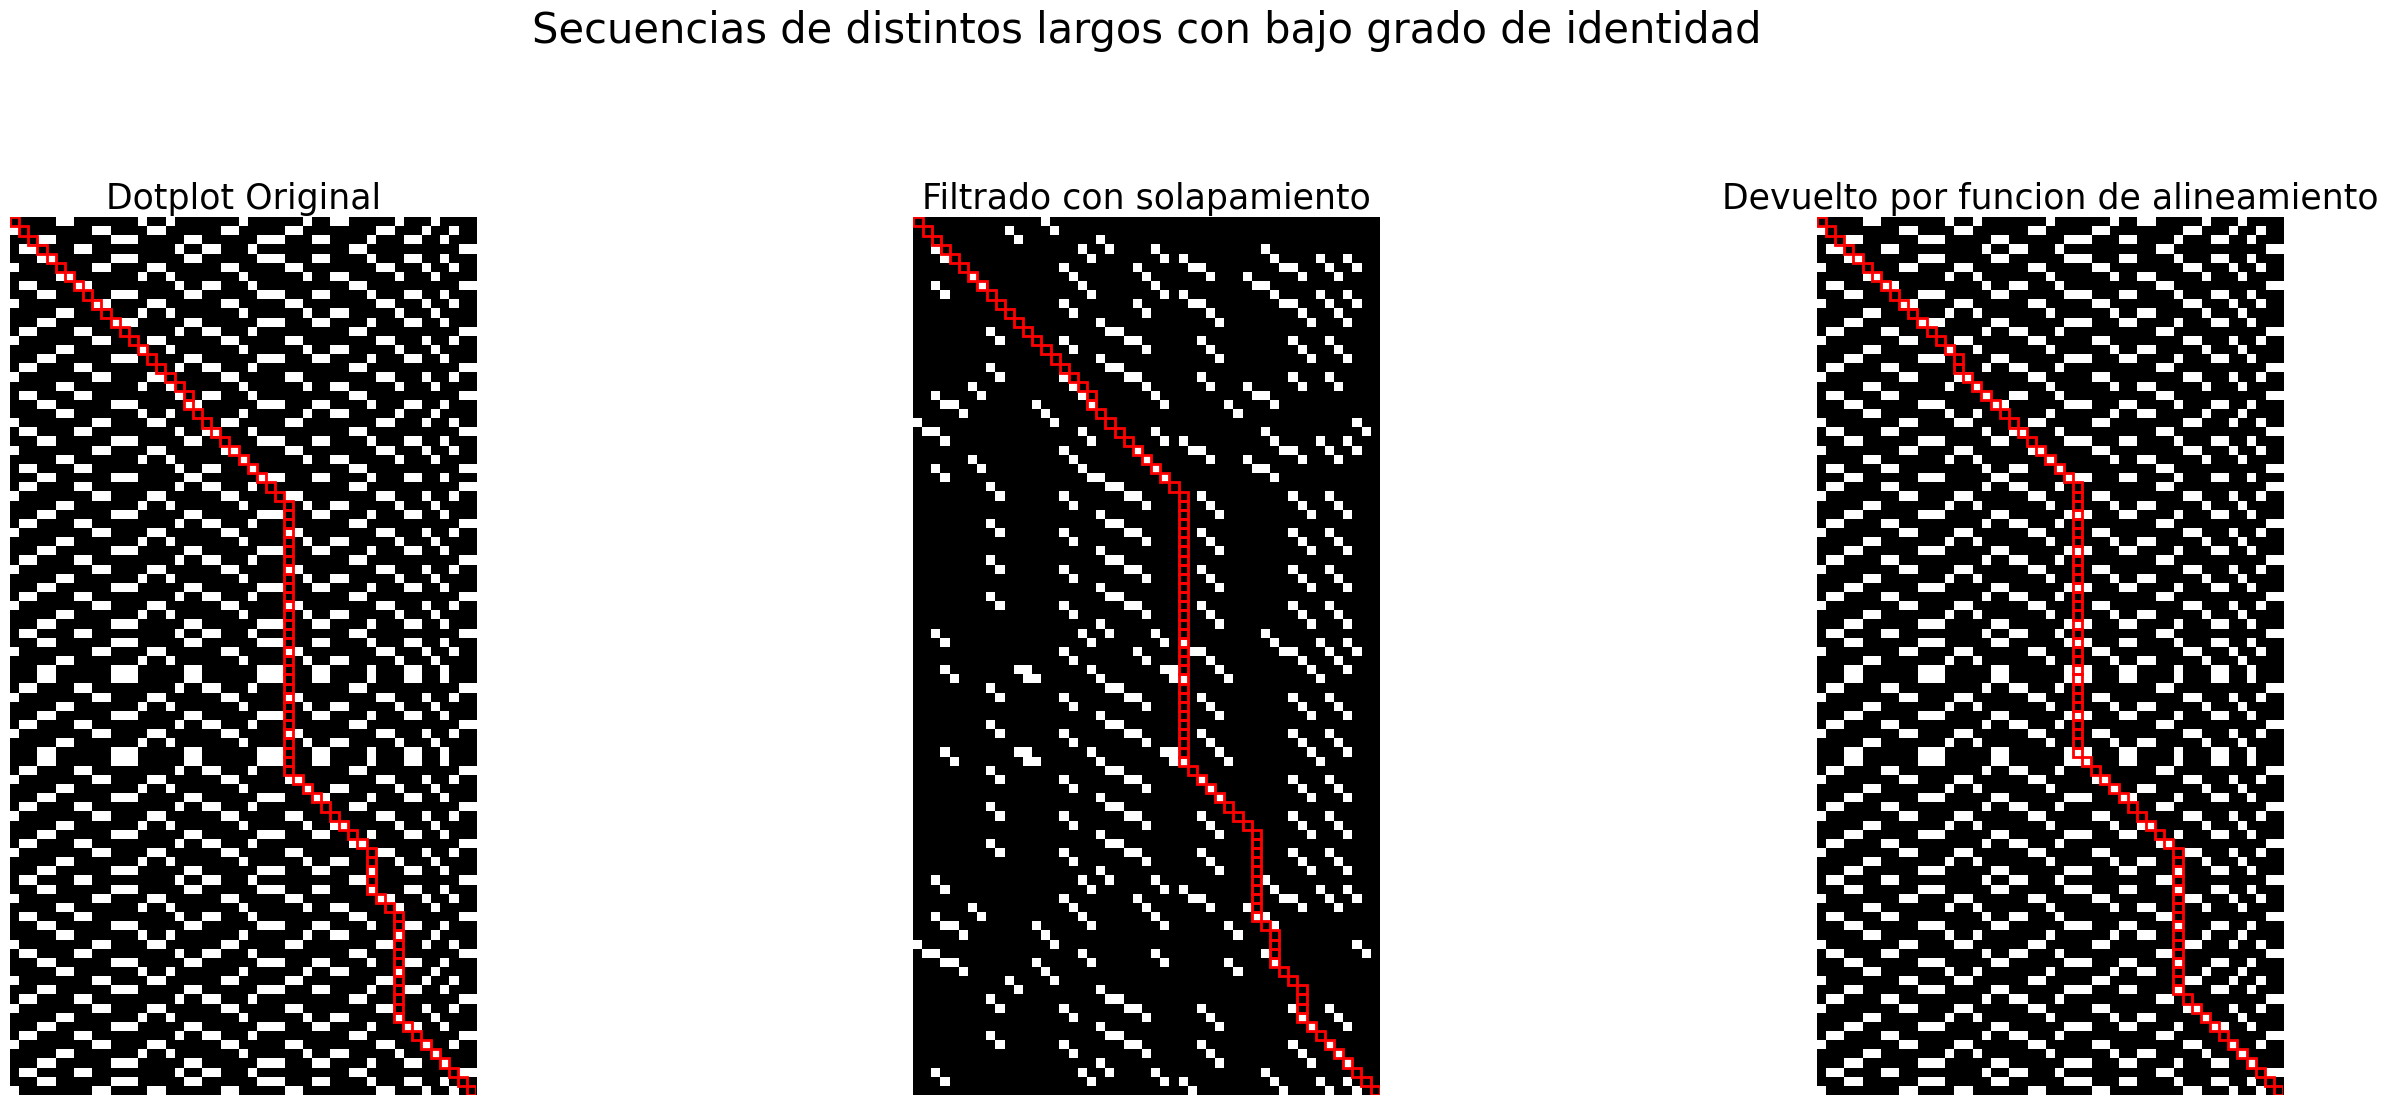

In [59]:
seq1 = "ATGCGTACGTAGCTAGCTACGATCGTACGCTAGCTAGCTAGCTAGCGTAGGCTAGCTAGGCTAGCTAGCTAGCGTACGATCGATGCTAGCTAGCGT"
seq2 = "TCCGGAACCTTGGGATTACGGCCTTACGGGTTAGGAACCGTTAGGTAGTCC"
evaluar_alineamientos(seq1,seq2, "Secuencias de distintos largos con bajo grado de identidad", MATCH, MISMATCH, GAP_OPEN, GAP_EXT)

# Los caminos en los dotplots generados por nuestros programas de alineamiento parecieran ser muy parecidos a aquel generado por el modulo Bio.pairwise2
### Ahora haremos un analisis comparativo de los scores de nuestro programa (variando los filtros) con el score del mencionado modulo

In [70]:
pares_de_secuencias = [

    # Par 1: alta identidad (~99%), longitudes 100 vs 200
    [
        "ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTA",
        "ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAATCGTAGCTAGC"
    ],


    # Par 2: alta identidad (~98%), longitudes 120 vs 250
    [
        "ATGAGACCATCATTCCGATATTGGAAGCCTCTACCCATAGTAATTCCGTGTCCCCAATCCTAGCAGGGGCATTGTGACCAATTAGTTAACAGGAACCATATCCTTTTTATTACACAGGCCAGGGTTTCCGACTAGGT",
        "ATGAGACCATCATTCCGATATTGGAAGCCTCTACCCATAGTAATTCCGTGTCCCCAATCCTAGCAGGGGCATTGTGACCAATTAGTTAACAGGAACCATATCCTTTTTATTACACAGGCCAGGGTTTCCGACTAGGTAGGGAAGGAAATAGCATTGTTGAAACGAAGTAGATGCCTATTATTAGTGCCTTTGGTAGGACCCAAATCTCAGATTTGGCTGCTCAGTTTCAACCTTGGGTAATTTGGAAGACGGCGTGGTAAAGAATTTGATTCGGTCGTAGGACCGTGCTATTCTATGAAGTTAATAGAGCTTCGGCTTCTTTGTACCCAGCAGGATGTAGATCGAGTTGTTAGCCTGAGCTATTGGTAGGAAAAGAACGGGCCCCGATCCAACAGTCAGTGGCTATAAAACATACGGTAGTGTTCACGAGGTCTTTTAGAGACTGCTGAACAGGGTTGGTAAACTGACCTAATTTATTGGGCTGCCTAGCTGAGAGGA"
    ],

    # Par 3: alta identidad (~97%), longitudes 200 vs 400
    [
        "ATGCCGTAGCTAGCTAGCTAGCTACGATCGTACGATCGATCGTAGCTAGCTAG",
        "ATGCCGTAGCTAGCTAGCTAGCTACGATCGTACGATCGATCGTAGCTAGCTAGCTAGCTAGCGTACGATCGATCGATCGTAGCTAGCTAGCGTACGATCGATCGATCGTAGCTAGCTAGCTGATCGA"
    ],
        # Par 4: alta identidad (~95%), longitudes 180 vs 220
    [
        "GCTAGCTAGCTAGCTAGCGATCGATCGTAGCTAGCTAGCTAGCGATCGTAGCTAGCTAGC",
        "GCTAGCTAGCTAGCTAGCGATCGATCGTAGCTAGCTAGCTAGCGATCGTAGCTAGCTAGCGATCGTAGCTAGCTAGCTAGCTAGC"
    ],

    # Par 5: identidad media (Humano vs Pez) — fragmento ~600 bp
    [
        "ATGAGACCATCATTCCGATATTGGAAGCCTCTACCCATAGTAATTCCGTGTCCCCAATCCTAGCAGG G CATTGTGACCAATTAGTTAACAGGAACCATATCCTTTTTATTACACAGGCCAGGGTTTCCGACTAGGTAGGGAAGGAAATAGCATTGTTGAAACGAAGTAGATGCCTATTATTAGTGCCTTTGGTAGGACCCAAATCTCAGATTTGGCTGCTCAGTTTCAACCTTGGGTAATTTGGAAGACGGCGTGGTAAAGAATTTGATTCGGTCGTAGGACCGTGCTATTCTATGAAGTTAATAGAGCTTCGGCTTCTTTGTACCCAGCAGGATGTAGAT",
        "ATGAGACTATCATCCCATTCTTGTAAGCCTGTGCCCATTGTAGTTTCCGTATCCGAGCAGGCCACCGTGGCACAATGGTTAACAGCAACCAATTCTTTTTATTGACAGGCCAGGGTTTCCGACTAGATAGGAAGGGAAGGAAATAACAATGTTGAAACGTAGTAGACGCCTATTATTAGTGCCTTTGGTAGGACTCCAAATCTCAGATTTGGCTGCTCAGTTTCAACCTTGGGTAATTTGGAAGATGGCGTGGTACAGAATTTGATTCGGTCATAGGACCGTGCTATTCTATGAAGTTAATAGAGCTTCGGCTTCTTTGTACCCAGCAGGAT"
    ],

    # Par 6: media identidad (~80%), longitudes 150 vs 300
    [
        "ACGACTGACGTCAGTACGTAGCTAGCTAGCGTACGATCGATCGTAGCTAAGCTAGCAGCTAGCTAGCTAGCTAGCTGACG",
        "ACGACTGACGTTAGTAGTTAGCTAGCTAGCGTACGATCGATCGTAGCTAAGCTAGCAGCTAGCTAGCTAGCTAGCTGACGACGTCAGTACGTAGCTAGCTAGCGTACGATCGATCGTAGCTAAGCTAGCAGCTAGCTAGCTAGC"
    ],

    # Par 7: media identidad (~75%), longitudes 120 vs 250
    [
        "ATGAGACCATCATTCCGATATTGGAAGCCTCTACCCATAGTAATTCCGTGT",
        "ATGAGTCCATCATTGCGATATTGGAAGCCTGTGCCCATTGTAGTTTCCGTATCCGAGCAGGCCACCGTGGCACAATGGTTAACAGCAACCAATTCTTTTTATTGACAGGCCAGGGTTTCCGACTAGATAGGAAGGGAAGGAA"
    ],

    # Par 8: identidad media (~85%), longitudes 150 vs 300
    [
        "ATGACCTAGTACGATCGATCGTAGCTAGCTAGCTAACGATCGTAGCTAGCTAGCTA",
        "ATGACCTAGTACGATCGATCGTGGGCTAGCTAACGATCATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAGCTA"
    ],

    # Par 9: identidad media (~78%), longitudes 220 vs 400
    [
        "ACGTACGTACGTAGCTAGCTAGCTAACGATCGTAGCTAGCTAGCTAAGCTAGC",
        "ACGTACGTACGTGGCTAGCTAACGATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAACGATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAGCTA"
    ],

    # Par 10: identidad media (~70%), longitudes 100 vs 220
    [
        "GCTAGCTAACGATCGTAGCTAGCTAGCTAAGCTAGC",
        "GCTAGCTAACGATCATAGCTGGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAACGATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAGCTA"
    ],

    # Par 11: baja identidad (~60%), longitudes 120 vs 250
    [
        "ATGACCTAGTACGATCGATCGTAGCTAGCTAGCTAAGCTAGC",
        "GGGACCTTGTACCATCGTACGTGGCTAACGATCGTGGCTAACGATCGTAGCTAACGATCGTGGCTAACGATCATCGTAGCTAGCTAGCTAAGCTAGC"
    ],

    # Par 12: baja identidad (~50%), longitudes 180 vs 360
    [
        "ACGTACGTAGCTAGCTAACGATCGTAGCTAGCTAAGCTAGC",
        "TTTACGGGAGCTTTCGAACCATCGTGGCTAACGATCGTGGCTAACGATCGTAGCTAACGATCGTGGCTAACGATCATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAGCTA"
    ],

    # Par 13: baja identidad (~45%), longitudes 90 vs 200
    [
        "GCTAGCTAACGATCGTAGCTAGCTAGCTAAGCTAGC",
        "CCGTAGGAACCTTCGTAACGTTACGGCTAACGATCGTGGCTAACGATCGTAGCTAACGATCGTGGCTAACGATCATCGTAGCTAGCTAGCTAAGCTAGCGTACG"
    ],

    # Par 14: baja identidad (~40%), longitudes 150 vs 300
    [
        "ATGACCTAGTACGATCGATCGTAGCTAGCTAGCTAAGCTAGC",
        "TTTGGGAAACCTTCGTAACGTTACGGCTAACGATCGTGGCTAACGATCGTAGCTAACGATCGTGGCTAACGATCATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCGATCGTAGCTAGCTA"
    ],

    # Par 15: baja identidad (~30%), longitudes 100 vs 220
    [
        "ACGTACGTAGCTAGCTAACGATCGTAGCTAGCTAAGCTAGC",
        "CCGGTTAAACCTTCGTAACGTTACGGCTAACGATCGTGGCTAACGATCGTAGCTAACGATCGTGGCTAACGATCATCGTAGCTAGCTAGCTAAGCTAGCGTACGATCG"
    ],
    # Par 16: identidad baja (Humano vs Pez) — fragmento ~300 bp
    [
        "GACCAATTAGTTAACAGGAACCATATCCTTTTTATTACACAGGCCAGGGTTTCCGACTAGGTAGGGAAGGAAATAGCATTGTTGAAACGAAGTAGATGCCTATTATTAGTGCCTTTGGTA",
        "TTGACAGGCCAGGGTTTCCGACTAGATAGGAAGGGAAGGAAACAACAATGTTGAAACGTAGTAGACGCCTATTATTAGTGCCCAGG--AGGACTCCCAAATCTCAGATTTGGCTGCTCAGTTTCA"
    ],
     # Par 17: baja identidad (~55%), longitudes 180 vs 350
    [
        "GACCAATTAGTTAACAGGAACCATATCCTTTTTATTACACAGGCCAGGGTTTCCGACTAGGTAGGGAAGGAA",
        "TTGACAGGCCAGGGTTTCCGACTAGATAGGAAGGGAAGGAAACAACAATGTTGAAACGTAGTAGACGCCTATTATTAGTGCCCAGGAGGACTCCCAAATCTCAGATTTGGCTGCTCAGTTTCAACCTTGGGTAATTTGGAAGATGGCGTGGTACAGA"
    ]

]






In [87]:
kernel_1 = np.array([[1,0,0],[0,0,0],[0,0,1]], dtype=np.uint8)
kernel_2 = np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=np.uint8)
kernel_3 = np.array([[1,0],[0,1]], dtype=np.uint8)
tuplas_kernel_umbral = [(kernel_1,1), (kernel_1,2),
                        (kernel_2,1), (kernel_2,2),
                        (kernel_3,1), (kernel_3,2)]

scores= []

for par in pares_de_secuencias:
    seq1, seq2 = par[0], par[1]
    #Alineamiento sin filtrar
    dotplot_original = generar_dotplot(seq1,seq2)
    _, score = mostrar_alineamiento(seq1, seq2, dotplot_original,'con alineamiento con dotplot original', MATCH, MISMATCH, GAP_OPEN, GAP_EXT, return_score = True)
    scores.append(score)
    #Alineamiento con Bio.pairwise2
    score = pairwise2.align.globalms(seq1, seq2, MATCH, MISMATCH, GAP_OPEN, GAP_EXT, score_only = True)
    scores.append(score)
    #Iteramos sobre las combinaciones kernel umbral
    for (kernel,umbral) in tuplas_kernel_umbral:
        dotplot_solapado = filtro_solapado(dotplot_original, kernel, umbral)
        _, score = mostrar_alineamiento(seq1, seq2, dotplot_solapado,'con alineamiento con dotplot filtrado por solapamiento', MATCH, MISMATCH, GAP_OPEN, GAP_EXT, True)
        scores.append(score)
    print('='*300)

scores_por_filtro = np.array(scores).reshape(17,8)
import pandas as pd
scores_df = pd.DataFrame(scores_por_filtro)
scores_df.columns = ["Dotplot original", "Bio.pairwise2", "Kernel 1 umbral 1", "Kernel 1 umbral 2", "Kernel 2 umbral 1", "Kernel 2 umbral 2", "Kernel 3 umbral 1", "Kernel 3 umbral 2"]

cols = [c for c in scores_df.columns if c != "Bio.pairwise2"] #Todos los alineamientos menos el de pairwise
df_pairwise = scores_df["Bio.pairwise2"]

df_diferencia_scores_normalizados = scores_df[cols].apply(
    lambda col: (col - df_pairwise).abs() / np.abs(np.maximum(col, df_pairwise)),
    axis=0
)

Score: 1 con alineamiento con dotplot original
ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTA-------------------------------------------------
ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAATCGTAGCTAGC
****************************************************                                                 
Score: 1 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTA-------------------------------------------------
ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAATCGTAGCTAGC
****************************************************                                                 
Score: 1 con alineamiento con dotplot filtrado por solapamiento
ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTA-------------------------------------------------
ATGCGTACGATCGTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAGCTAGCTAGCTAGCGTACGATCGTAGCTAGCTAGCTAATCGTAGCTAGC
*********

In [103]:
display(df_diferencia_scores_normalizados)

,Dotplot original,Kernel 1 umbral 1,Kernel 1 umbral 2,Kernel 2 umbral 1,Kernel 2 umbral 2,Kernel 3 umbral 1,Kernel 3 umbral 2
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.081081,0.092664,0.065637,0.081081,0.092664,0.081081,0.065637
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.019608,0.019608,0.058824,0.019608,0.019608,0.019608,0.058824
7,0.300000,0.300000,0.300000,0.300000,0.300000,0.300000,0.200000
8,0.166667,0.166667,0.055556,0.166667,0.166667,0.166667,0.055556
9,0.026316,0.026316,0.000000,0.026316,0.026316,0.026316,0.000000


Aqui podemos observar la diferencia absoluta entre el score del modulo pairwise y cada uno de los filtros utilizados, normalizada por el absoluto del maximo entre ambos scores.

Dicha metrica, por consecuente, tiene a cero como mejor valor (alineamientos identicos) y a uno como peor valor.

Para visualizarlo mejor, mostramos el siguiente mapa de calor, transponiendo el dataframe.


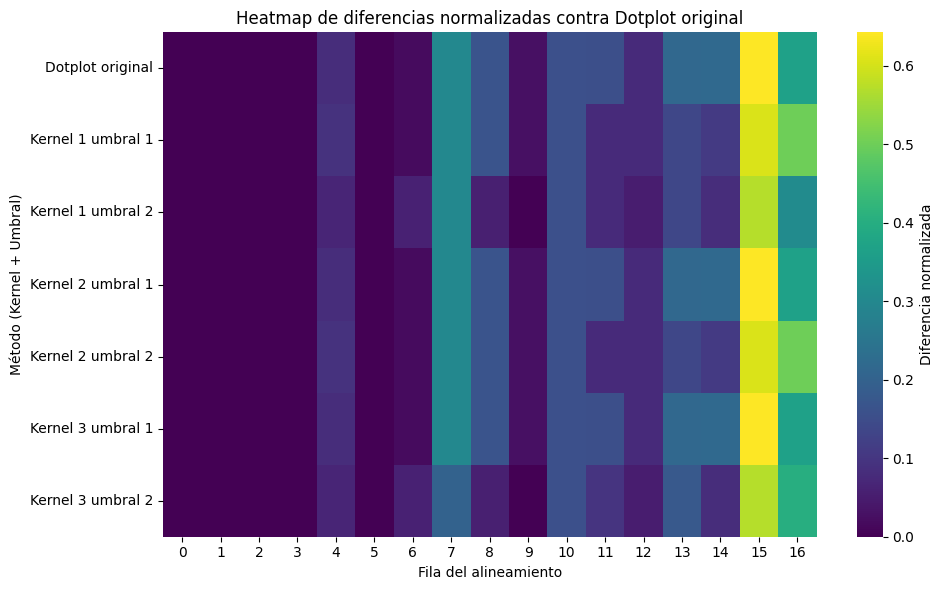

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    df_diferencia_scores_normalizados.T,
    cmap="viridis",
    annot=False,
    cbar_kws={'label': 'Diferencia normalizada'}
)
plt.title("Heatmap de diferencias normalizadas contra Dotplot original")
plt.ylabel("Método (Kernel + Umbral)")
plt.xlabel("Fila del alineamiento")
plt.tight_layout()
plt.show()


Podemos observar como la metrica calculada es bastante uniforme respecto a los filtros, dada una secuencia el valor es bastante similar.

- Las secuencias de alta identidad (0 a 3) tienen error cero.
- Las secuencias de media identidad(4 a 9) muestran valores distintos a cero, siendo la septima la de mayor error.
- Las secuencias de baja identidad (10 a 16) devolvieron errores todos mayores a cero, siendo las instancias 15 y 16 las que mas difieren del alineamiento de la funcion pairwise.

Concluimos que nuestro algoritmo de alineamiento de secuencias de adn generalmente funciona bien para secuencias de alta y mediana identidad; mientras que con las de baja identidad no se desempeña correctamente, aunque en 5 de las 7 de estas ultimas secuencias la metrica ha sido menor a 0.22, siendo un resultado aceptable.